In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
from loguru import logger
from beartype import beartype
from typing import Union, Literal

from datetime import timedelta

# !pip3 install tqdm

np.random.seed(42)

from scipy.optimize import minimize
from scipy.stats import norm
from tqdm import tqdm
from pathlib import Path
from loguru import logger
from beartype import beartype
from typing import Union, Literal


### Returns Matrix

In [183]:
@beartype
def get_etfs_returns(df: dict[str, pd.DataFrame], type: Literal['returns', 'log-returns'] = 'log-returns') ->  pd.DataFrame:
    returns_df = pd.DataFrame()
    for ticker in df.keys():
        df_ticker = df[ticker]
        if set(['Date', type]) <= set(df_ticker.columns):
            df_ticker = df_ticker[['Date', type]]
            df_ticker = df_ticker.rename(columns={type: ticker})
        
        if returns_df.empty:
            returns_df = df_ticker
        else:
            returns_df = pd.merge(returns_df, df_ticker, on='Date')
            
    return returns_df


@beartype
def get_first_day_month_returns(
    returns_df: pd.DataFrame,
    filtered_etfs: list,
    startTime: Union[str, pd.Timestamp, None],
    endTime: Union[str, pd.Timestamp, None]):
    
    if startTime and endTime:
        month_return = returns_df[(returns_df['Date'] >= startTime) & (returns_df['Date'] < endTime)]
    
    elif startTime:
        month_return = returns_df[returns_df['Date'] >= endTime]
        
    elif endTime:
        month_return = returns_df[returns_df['Date'] < endTime]
        
    else:
        raise ValueError(f'Two dates startTime and endTime both None, but we need that one of them will be at least not None')
    
    return month_return[['Date']+filtered_etfs]


@beartype
def get_rebalanced_returns_dict(
    first_business_days: pd.Series,
    returns_df: pd.DataFrame,
    portfolios: dict[pd.Timestamp, dict[str, int]],
    save_path: Union[Path, None] = None
) -> dict[str, pd.DataFrame]:
    
    startTime = None
    returns_dict = {}
    for rebalance_day in first_business_days:
        returns_rebalanced = get_first_day_month_returns(returns_df, sorted(portfolios[rebalance_day].keys()), startTime, endTime=rebalance_day)
        returns_dict.update({rebalance_day.strftime("%Y-%m-%d"): returns_rebalanced})
        startTime = rebalance_day

    save_df_dict_to_excel(returns_dict, save_path=save_path, filename='returns_rebalance.xlsx')

    return returns_dict


In [ ]:
sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
portfolios = pd.read_excel(save_path / "portfolio_rebalance.xlsx", sheet_name=sheet_names_str)
portfolios


{'2016-02-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 115  VSDA      1
 116   VTC      1
 117  VTHR      1
 118  VYMI      1
 119  WCLD      1
 
 [120 rows x 2 columns],
 '2016-03-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 117   VTC      1
 118  VTHR      1
 119  VTIP      1
 120  VYMI      1
 121  WCLD      1
 
 [122 rows x 2 columns],
 '2016-04-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 121   VTC      1
 122  VTHR      1
 123  VTIP      1
 124  VYMI      1
 125  WCLD      1
 
 [126 rows x 2 columns],
 '2016-05-02':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 123   VTC      1
 124  VTHR      1
 125  VTIP      1
 126  VYMI      1
 127  WCLD      1

In [ ]:
returns_df = get_etfs_returns(df_stats)
returns_dict = get_rebalanced_returns_dict(first_business_days, returns_df, final_portfolio)
returns_dict


{'2016-02-01':          Date      BSCK      BSCP      BSCS      BSCT      BSCU      BSCV  \
 0  2016-01-04       NaN       NaN       NaN       NaN       NaN       NaN   
 1  2016-01-05 -0.001561  0.006895  0.006794 -0.000939  0.000239  0.003039   
 2  2016-01-06 -0.009419 -0.010894 -0.013842 -0.012760 -0.022451 -0.016000   
 3  2016-01-07 -0.031511 -0.021878 -0.018476 -0.026752 -0.030489 -0.019641   
 4  2016-01-08 -0.011460 -0.012088 -0.015590 -0.010806 -0.015473 -0.013884   
 5  2016-01-11 -0.001098 -0.000830  0.001506 -0.002472 -0.001279 -0.001964   
 6  2016-01-12  0.012558  0.008813  0.008986  0.010832  0.013979  0.005392   
 7  2016-01-13 -0.035906 -0.024144 -0.030492 -0.036658 -0.033362 -0.026252   
 8  2016-01-14  0.017838  0.011729  0.015254  0.017125  0.019127  0.011477   
 9  2016-01-15 -0.022912 -0.015387 -0.017673 -0.029392 -0.038361 -0.020552   
 10 2016-01-19 -0.003398  0.004781  0.002857 -0.000257 -0.001864 -0.003043   
 11 2016-01-20 -0.006259 -0.015837 -0.003959 -0.00

### Research stuff

In [253]:
import os
import argparse
# import plumbum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# import plotly.graph_objects as go

from pandas.tseries.offsets import CustomBusinessDay
from pandas.tseries.holiday import USFederalHolidayCalendar

from tqdm import tqdm
from pathlib import Path
from loguru import logger
from beartype import beartype
from datetime import timedelta
from typing import Union, Literal


In [10]:
save_path = Path('../datasets/')
path = Path("../datasets/Portfolio ETF NASDAQ Data.xlsx")
os.path.exists(path)


True

In [164]:
tickers = pd.read_excel(save_path / "tickers.xlsx", index_col=0)
tickers = tickers.iloc[:, 0].tolist()

df_stats = pd.read_excel(save_path / "etf_nasdaq.xlsx", sheet_name=tickers)
df_stats


{'AAPU':            Date  OpenPrice  ClosePrice  MinPrice  MaxPrice        Volume  \
 0    2016-01-04        NaN         NaN       NaN       NaN           NaN   
 1    2016-01-05        NaN         NaN       NaN       NaN           NaN   
 2    2016-01-06        NaN         NaN       NaN       NaN           NaN   
 3    2016-01-07        NaN         NaN       NaN       NaN           NaN   
 4    2016-01-08        NaN         NaN       NaN       NaN           NaN   
 ...         ...        ...         ...       ...       ...           ...   
 2499 2025-12-24      39.52     39.4650   39.4650     39.52  3.090014e+04   
 2500 2025-12-26      39.48     39.4231   39.3750     39.48  3.230361e+05   
 2501 2025-12-29      39.39     39.3703   39.3703     39.39  1.684637e+05   
 2502 2025-12-30      39.38     39.3517   39.3517     39.42  2.714249e+06   
 2503 2025-12-31      39.23     39.0683   39.0100     39.23  5.693200e+05   
 
         AUM (USD)  DistrAmount  PayableDate  MidPrice    Spread  

In [12]:
first_business_days = pd.read_excel(save_path / "business_dates.xlsx", index_col=0)
first_business_days = first_business_days['Values'].iloc[1:]
first_business_days


1     2016-02-01
2     2016-03-01
3     2016-04-01
4     2016-05-02
5     2016-06-01
         ...    
115   2025-08-01
116   2025-09-02
117   2025-10-01
118   2025-11-03
119   2025-12-01
Name: Values, Length: 119, dtype: datetime64[ns]

In [13]:
sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
portfolios = pd.read_excel(save_path / "portfolio_rebalance.xlsx", sheet_name=sheet_names_str)
portfolios


{'2016-02-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 115  VSDA      1
 116   VTC      1
 117  VTHR      1
 118  VYMI      1
 119  WCLD      1
 
 [120 rows x 2 columns],
 '2016-03-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 117   VTC      1
 118  VTHR      1
 119  VTIP      1
 120  VYMI      1
 121  WCLD      1
 
 [122 rows x 2 columns],
 '2016-04-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 121   VTC      1
 122  VTHR      1
 123  VTIP      1
 124  VYMI      1
 125  WCLD      1
 
 [126 rows x 2 columns],
 '2016-05-02':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 123   VTC      1
 124  VTHR      1
 125  VTIP      1
 126  VYMI      1
 127  WCLD      1

In [14]:
returns_dict = pd.read_excel(save_path / "returns_rebalance.xlsx", sheet_name=sheet_names_str)
returns_dict


{'2016-02-01':          Date      BSCK      BSCP      BSCQ      BSCS      BSCT      BSCU  \
 0  2016-01-04  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 1  2016-01-05 -0.001561  0.006895  0.004404  0.006794 -0.000939  0.000239   
 2  2016-01-06 -0.009419 -0.010894 -0.024787 -0.013842 -0.012760 -0.022451   
 3  2016-01-07 -0.031511 -0.021878 -0.052852 -0.018476 -0.026752 -0.030489   
 4  2016-01-08 -0.011460 -0.012088 -0.004760 -0.015590 -0.010806 -0.015473   
 5  2016-01-11 -0.001098 -0.000830 -0.007527  0.001506 -0.002472 -0.001279   
 6  2016-01-12  0.012558  0.008813 -0.006201  0.008986  0.010832  0.013979   
 7  2016-01-13 -0.035906 -0.024144 -0.036598 -0.030492 -0.036658 -0.033362   
 8  2016-01-14  0.017838  0.011729  0.005718  0.015254  0.017125  0.019127   
 9  2016-01-15 -0.022912 -0.015387 -0.031128 -0.017673 -0.029392 -0.038361   
 10 2016-01-19 -0.003398  0.004781 -0.016309  0.002857 -0.000257 -0.001864   
 11 2016-01-20 -0.006259 -0.015837  0.011887 -0.00

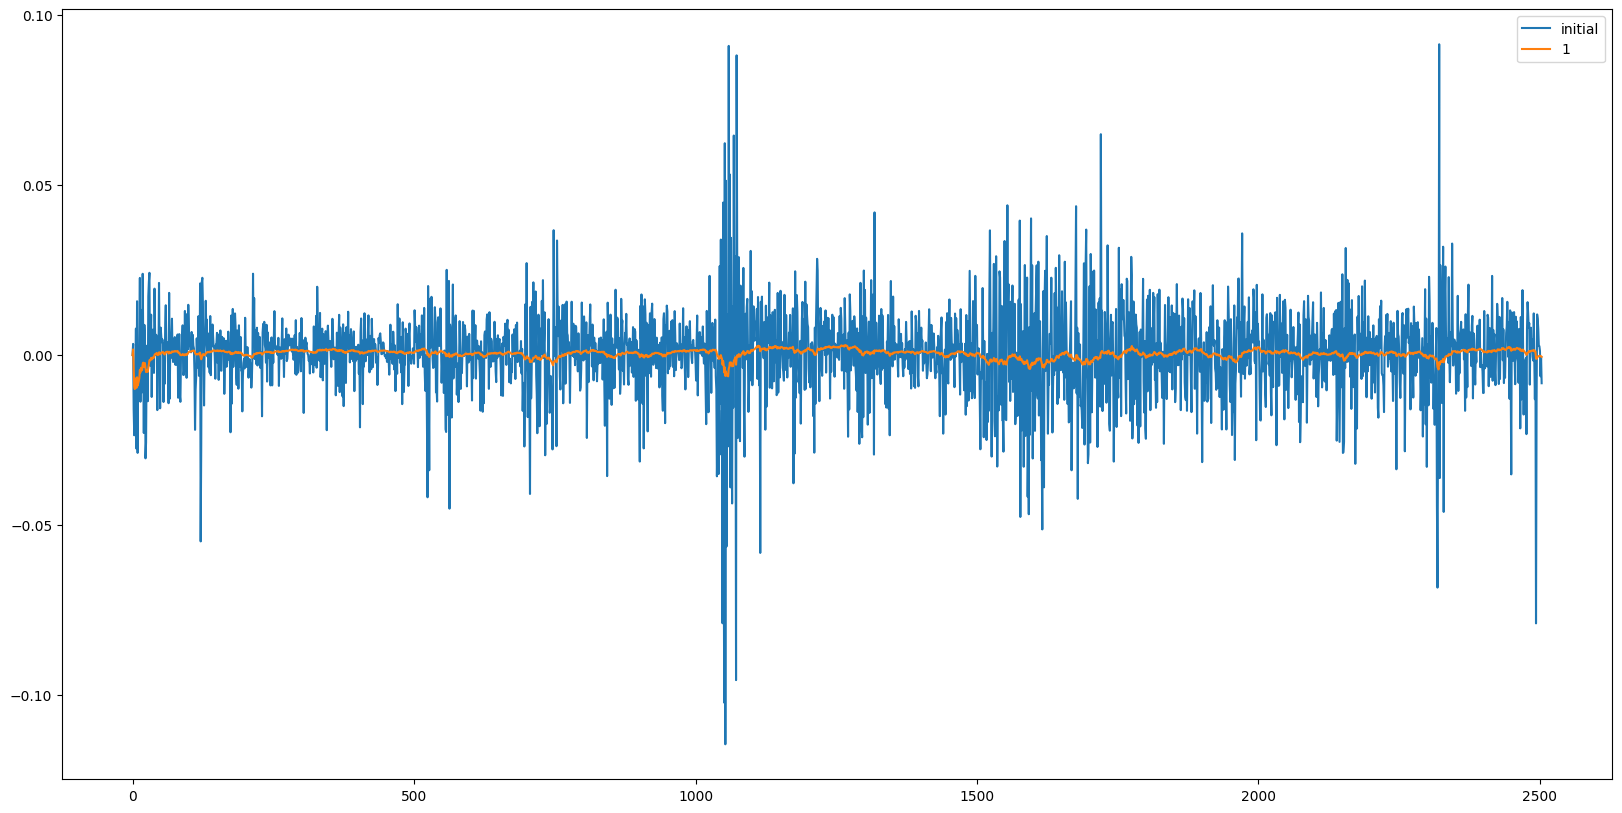

In [166]:
df = df_stats[tickers[200]]
window = 30

df[f'EMA{window}_1'] = df['log-returns'].ewm(halflife=window, adjust=True).mean()
df[f'EMA{window}_2'] = df['log-returns'].ewm(span=window, adjust=True).mean()

plt.figure(figsize=(20, 10))
plt.plot(df['log-returns'], label='initial')
# plt.plot(df[f'EMA{window}_2'], label='2')
plt.plot(df[f'EMA{window}_1'], label='1')
plt.legend()


In [ ]:
df_stats = get_merge_statistics(df_dict, etf_ids, save_path)


,Date,OpenPrice,LastPrice,MinPrice,MaxPrice,Volume,AUM (USD),DistrAmount,PayableDate,MidPrice,Spread,AskPrice,BidPrice,log-returns,EMA30
0,2016-01-04,24.51,24.3400,24.17,24.540,1.623478e+06,NaN,0.194490,2015-12-28,24.3550,NaN,NaN,NaN,0.000000,0.000000
1,2016-01-05,24.43,24.4200,24.29,24.460,1.531134e+06,NaN,0.194490,2015-12-28,24.3750,NaN,NaN,NaN,0.003281,0.001660
2,2016-01-06,24.07,24.0300,23.87,24.140,7.473330e+05,NaN,0.194490,2015-12-28,24.0050,0.000000,24.005000,24.005000,-0.016099,-0.004397
3,2016-01-07,23.62,23.4700,23.39,23.820,2.229650e+06,NaN,0.194490,2015-12-28,23.6050,0.000000,23.605000,23.605000,-0.023580,-0.009360
4,2016-01-08,23.75,23.1800,23.15,23.750,1.458022e+06,NaN,0.194490,2015-12-28,23.4500,0.022890,23.461445,23.438555,-0.012433,-0.010004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,2025-12-24,70.52,70.7144,70.52,70.760,4.007867e+06,3.615989e+09,5.332248,2025-12-19,70.6400,0.002977,70.641489,70.638511,0.002617,-0.000224
2500,2025-12-26,70.82,70.8009,70.67,70.880,6.823902e+06,3.619408e+09,5.332248,2025-12-19,70.7750,0.005648,70.777824,70.772176,0.001222,-0.000191
2501,2025-12-29,70.33,70.3600,70.26,70.525,6.134283e+06,3.598133e+09,5.332248,2025-12-19,70.3925,0.000000,70.392500,70.392500,-0.006247,-0.000329
2502,2025-12-30,70.46,70.3200,70.32,70.550,9.094007e+06,3.594886e+09,5.332248,2025-12-19,70.4350,0.006749,70.438375,70.431625,-0.000569,-0.000335


In [33]:
df_dict = filter_business_dates(df_dict)
df_dict


{'Meta':               ISIN Тикер                                        ETF & Funds  \
 0     US3015056738  SIXS              6 Meridian Small Cap Equity ETF (USD)   
 1     US26922B4858  BDIV            AAM Brentview Dividend Growth ETF (USD)   
 2     US26922A5948  SPDV          AAM S&P 500 High Dividend Value ETF (USD)   
 3     US26922A3471  DMDV  AAM S&P Developed Markets High Dividend Value ...   
 4     US26922A5864  EEMD  AAM S&P Emerging Markets High Dividend Value E...   
 ...            ...   ...                                                ...   
 3644  US46434VAQ32  IBDL  iShares® iBonds® Dec 2020 Term Corporate ETF (...   
 3645  US46432FBC05  IBDC  iShares® iBonds® Mar 2020 Term Corporate ETF (...   
 3646  US46432FAK30  IBCD  iShares® iBonds® Mar 2020 Term Corporate ex-Fi...   
 3647  US46429B5646  IBMH  iShares® iBonds® Sep 2019 Term Muni Bond ETF (...   
 3648  US46434V5710  IBMI  iShares® iBonds® Sep 2020 Term Muni Bond ETF (...   
 
                       Провайд

In [ ]:
@beartype
def cosmetic_changes(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
    def replace(df: pd.DataFrame) -> pd.DataFrame:
        for col in df.columns[1:]:
            df[col] = df[col].mask(df[col] == 'No data', np.nan)
            if any(',' in str(x) for x in df[col]): df[col] = df[col].str.replace(',', '.').astype('float')
            if any(str(x).count('.') == 2 for x in df[col]): df[col] = pd.to_datetime(df[col].str.replace('.', '-'), dayfirst=True)

        return df
        
    if isinstance(df, dict):
        for code in df.keys():
            df[code] = replace(df[code])
    
    elif isinstance(df, pd.DataFrame):
        df = replace(df)
    
    else:
        raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")
        
    return df


@beartype
def filling_values(df: Union[dict[str, pd.DataFrame]]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:    
    def fill_na_values(df: pd.Series, window=20) -> pd.Series:
        # Special condition that check if all values of series is numbers, not strings
        if not np.issubdtype(df.dtype, np.number):
            return df
        
        start = df.index[~df.isna()][0]
        end = len(df)
        
        df = df.copy()
        for i in range(start, end):
            if pd.isna(df.iloc[i]):
                df.iloc[i] = df.iloc[start:i].mean() if i - start < window else df.iloc[i-window-1:i].mean()
                
        return df
    
    def fill_df(df: pd.DataFrame) -> pd.DataFrame:
        for i in df.columns[1:-1]:
            df[i] = fill_na_values(df[i])            
        return df
    
    if isinstance(df, dict):
        for code in df.keys():
            df[code] = fill_df(df[code])
        return df
                
    elif isinstance(df, pd.DataFrame):
        return fill_df(df)
    
    else:
        raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")


@beartype
def get_merge_statistics(
    df_dict: dict[str, pd.DataFrame],
    etf_ids: dict,
    save_path: Union[Path, None] = None,
    filename: Union[str, None] = "etf_nasdaq.xlsx"
) -> dict[str, pd.DataFrame]:

    etf_codes = etf_ids.keys()
    tickers = etf_ids.values()
    print(etf_codes)
    print(tickers)
    df_stats = {ticker: pd.DataFrame() for ticker in tickers}
    
    pbar = tqdm(NAMES, desc='Merging Process')
    for name in pbar:
        pbar.set_description(f'Merging Process on {name}')
        df = df_dict[name]
        df = df.loc[:, ~df.columns.duplicated()]
        print(df.columns)
        print(name, set(etf_codes) <= set(df.columns) or set(df.columns[1:]) <= set(etf_codes))
        
        if set(etf_codes) <= set(df.columns) or set(df.columns[1:]) <= set(etf_codes):
            df = df.rename(columns={col: f'{name} {etf_ids[col]}' for col in df.columns[1:] if col in etf_codes})
            
            for ticker in tickers:
                df_stats[ticker] = pd.merge(df_stats[ticker], df[['Date', f'{name} {ticker}']], on='Date') if not df_stats[ticker].empty else df[['Date', f'{name} {ticker}']]
                df_stats[ticker] = df_stats[ticker].rename(columns={f'{name} {ticker}': name})

        # else:
        #     logger.info(f'For Statistics skip dict key {name}')

    # df_stats = cosmetic_changes(df_stats)
    # df_stats = filling_values(df_stats)
    
    # save_df_dict_to_excel(df_stats, save_path, filename=filename)
        
    return df_stats


df_stats = get_merge_statistics(df_dict, etf_ids)
df_stats


dict_keys(['CA85207Q1046', 'IE00B0M63623', 'IE00B23D8S39', 'IE00B8FHGS14', 'KYG407051088', 'US00039J1034', 'US00039J2024', 'US00039J3014', 'US00039J4004', 'US00039J5092', 'US00039J6082', 'US00039J7072', 'US00039J7494', 'US00039J7569', 'US00039J7643', 'US00039J7726', 'US00039J7809', 'US00039J7981', 'US00039J8062', 'US00039J8146', 'US00039J8229', 'US00039J8302', 'US00039J8484', 'US00039J8559', 'US00039J8633', 'US00039J8716', 'US00039J8898', 'US00110G4082', 'US00162Q1067', 'US00162Q2057', 'US00162Q3386', 'US00162Q3469', 'US00162Q3535', 'US00162Q4111', 'US00162Q4459', 'US00162Q4525', 'US00162Q4608', 'US00162Q4780', 'US00162Q5100', 'US00162Q5282', 'US00162Q5365', 'US00162Q5449', 'US00162Q5936', 'US00162Q6686', 'US00162Q6769', 'US00162Q7189', 'US00162Q7262', 'US00162Q7833', 'US00162Q8583', 'US00214Q1040', 'US00214Q4010', 'US00214Q7088', 'US0032601066', 'US0032611040', 'US0032612030', 'US0032616098', 'US0032621023', 'US0032631006', 'US0032641088', 'US00326A1043', 'US00384X2027', 'US00384X3017

Merging Process on OpenPrice:   0%|          | 0/8 [00:00<?, ?it/s]

Index(['ISIN', 'Тикер', 'ETF & Funds', 'Провайдер', 'Объект инвестирования',
       'Сектор инвестирования', 'География инвестирования',
       'Коэффициент общих расходов, %', 'Биржа', 'Метод репликации'],
      dtype='object')
Meta False
Index(['Date', 'US3015056738', 'US26922B4858', 'US26922A5948', 'US26922A3471',
       'US26922A5864', 'US26922B6838', 'US00039J8229', 'US00039J4004',
       'US00039J3014',
       ...
       'US46438G3801', 'US4642885135', 'US4642872422', 'US46434VAA89',
       'US46434VAU44', 'US46434VAQ32', 'US46432FBC05', 'US46432FAK30',
       'US46429B5646', 'US46434V5710'],
      dtype='object', length=3650)
OpenPrice True
3650


Merging Process on ClosePrice:  25%|██▌       | 2/8 [00:00<00:02,  2.77it/s]

Index(['Date', 'US3015056738', 'US26922B4858', 'US26922A5948', 'US26922A3471',
       'US26922A5864', 'US26922B6838', 'US00039J8229', 'US00039J4004',
       'US00039J3014',
       ...
       'US46438G3801', 'US4642885135', 'US4642872422', 'US46434VAA89',
       'US46434VAU44', 'US46434VAQ32', 'US46432FBC05', 'US46432FAK30',
       'US46429B5646', 'US46434V5710'],
      dtype='object', length=3650)
ClosePrice True
3650


Merging Process on Dividends:  75%|███████▌  | 6/8 [00:03<00:00,  2.27it/s] 

Index(['Date', 'US3015056738', 'US26922B4858', 'US26922A5948', 'US26922A3471',
       'US26922A5864', 'US26922B6838', 'US00039J8229', 'US00039J4004',
       'US00039J3014',
       ...
       'US46436E8416', 'US46436E8333', 'US46436E8259', 'US46436E5933',
       'US46436E4605', 'US46436E2963', 'US46436E1486', 'US46438G6465',
       'US46438G4221', 'US46438G6382'],
      dtype='object', length=2679)
MinPrice False
Index(['Date', 'US3015056738', 'US26922B4858', 'US26922A5948', 'US26922A3471',
       'US26922A5864', 'US26922B6838', 'US00039J8229', 'US00039J4004',
       'US00039J3014',
       ...
       'US46436E4605', 'US46436E2963', 'US46436E1486', 'US46438G6465',
       'US46438G4221', 'US46438G6382', 'US46438G4148', 'US46438G6200',
       'US46438G3983', 'US46436E7004'],
      dtype='object', length=2683)
MaxPrice False
Index(['Date', 'US3015056738', 'US26922B4858', 'US26922A5948', 'US26922A3471',
       'US26922A5864', 'US26922B6838', 'US00039J8229', 'US00039J4004',
       'US00039J30

Merging Process on Dividends: 100%|██████████| 8/8 [00:05<00:00,  1.49it/s]


{'AAA':            Date OpenPrice ClosePrice Dividends
 0    2016-01-04   No data    No data   No data
 1    2016-01-05   No data    No data   No data
 2    2016-01-06   No data    No data   No data
 3    2016-01-07   No data    No data   No data
 4    2016-01-08   No data    No data   No data
 ...         ...       ...        ...       ...
 2499 2025-12-24     18,61      17,93   No data
 2500 2025-12-26     18,82      19,94   No data
 2501 2025-12-29      17,7      17,26   No data
 2502 2025-12-30     17,79       17,6   No data
 2503 2025-12-31     16,88      16,84   No data
 
 [2504 rows x 4 columns],
 'AAAU':            Date OpenPrice ClosePrice Dividends
 0    2016-01-04     12,33      12,38    0,8201
 1    2016-01-05     12,36      12,34   No data
 2    2016-01-06     12,12      12,06   No data
 3    2016-01-07     11,77      11,78   No data
 4    2016-01-08     11,88      11,72   No data
 ...         ...       ...        ...       ...
 2499 2025-12-24   No data    No data   No da

In [ ]:
INPUT_PATH = Path.cwd().parent / "datasets" / "csv"

NAMES = [
    'Meta',
    'OpenPrice',
    'ClosePrice',
    'MinPrice',
    'MaxPrice',
    'Volume',
    'AUM',
    'Dividends',
]


@beartype
def get_dict_by_parsing_csv() -> dict[str, pd.DataFrame]:
    df_dict = {}
    for idx, name in enumerate(NAMES):
        if os.path.exists(INPUT_PATH / f'{name}.csv'):
            df_dict.update({name: pd.read_csv(INPUT_PATH / f'{name}.csv')})
            
            if idx == 0:
                df_dict[name] = df_dict[name].drop_duplicates(subset=['Тикер'], keep='first')
            
        else:
            raise FileNotFoundError(f"Not found file {INPUT_PATH / f'{name}.csv'}")

    return df_dict


@beartype
def get_etf_codes(df: pd.DataFrame, name: str) -> list:
    """
    we know that name == 'ISIN' a code, but using general function for further using
    """
    try:
        return sorted(df[name].astype('str'))
    except:
        raise TypeError(f"Column name {name} doesn't exist in this Dataframe or maybe dataframe is empty")


In [270]:
df_dict = get_dict_by_parsing_csv()
df_dict


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_32579/1825546269.py:20: DtypeWarning:

Columns (2368,2369) have mixed types. Specify dtype option on import or set low_memory=False.



{'Meta':               ISIN Тикер                                        ETF & Funds  \
 0     US3015056738  SIXS              6 Meridian Small Cap Equity ETF (USD)   
 1     US26922B4858  BDIV            AAM Brentview Dividend Growth ETF (USD)   
 2     US26922A5948  SPDV          AAM S&P 500 High Dividend Value ETF (USD)   
 3     US26922A3471  DMDV  AAM S&P Developed Markets High Dividend Value ...   
 4     US26922A5864  EEMD  AAM S&P Emerging Markets High Dividend Value E...   
 ...            ...   ...                                                ...   
 3549  US46438G6382  IBGA    iShares iBonds Dec 2044 Term Treasury ETF (USD)   
 3550  US46438G4148  IBGB    iShares iBonds Dec 2045 Term Treasury ETF (USD)   
 3551  US46438G6200  IBGK    iShares iBonds Dec 2054 Term Treasury ETF (USD)   
 3552  US46438G3983  IBGL    iShares iBonds Dec 2055 Term Treasury ETF (USD)   
 3553  US46436E7004  IBTA  iShares® iBonds® Dec 2021 Term Treasury ETF (USD)   
 
                       Провайд

In [ ]:
@beartype
def cosmetic_changes(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
    def replace(df: pd.DataFrame) -> pd.DataFrame:
        for col in df.columns[1:]:
            df[col] = df[col].mask(df[col] == 'No data', np.nan)
            if any(',' in str(x) for x in df[col]): df[col] = df[col].str.replace(',', '.').astype('float')
            if any(str(x).count('.') == 2 for x in df[col]): df[col] = pd.to_datetime(df[col].str.replace('.', '-'), dayfirst=True)

        return df
        
    if isinstance(df, dict):
        for code in df.keys():
            if code != NAMES[0]:
                df[code] = replace(df[code])
    
    elif isinstance(df, pd.DataFrame):
        df = replace(df)
    
    else:
        raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")
        
    return df


@beartype
def filter_business_dates(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
    def sort_dates(df: pd.DataFrame) -> pd.DataFrame:
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date')
            return df.reset_index(drop=True)

        return df
    
    def get_only_business_dates(df: pd.DataFrame) -> pd.DataFrame:
        """
        Removing weekends (that's Saturday and Sunday, saving only dates from Monday to Friday inclusive) and removing holidays
        """
        if 'Date' in df.columns:
            all_business_dates = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq=CustomBusinessDay(calendar=USFederalHolidayCalendar()))
            df = df[df['Date'].isin(all_business_dates)]
        
        return df.reset_index(drop=True)
    
    if isinstance(df, dict):
        for code in df.keys():
            df[code] = sort_dates(df[code])
            df[code] = get_only_business_dates(df[code])
        
    elif isinstance(df, pd.DataFrame):
        df = sort_dates(df)
        df = get_only_business_dates(df)
        
    else:
        raise TypeError(f'Wrong type of df {type(df)}')
    
    return df

df_dict = cosmetic_changes(df_dict)
df_dict = filter_business_dates(df_dict)
df_dict


{'Meta':               ISIN Тикер                                        ETF & Funds  \
 0     US3015056738  SIXS              6 Meridian Small Cap Equity ETF (USD)   
 1     US26922B4858  BDIV            AAM Brentview Dividend Growth ETF (USD)   
 2     US26922A5948  SPDV          AAM S&P 500 High Dividend Value ETF (USD)   
 3     US26922A3471  DMDV  AAM S&P Developed Markets High Dividend Value ...   
 4     US26922A5864  EEMD  AAM S&P Emerging Markets High Dividend Value E...   
 ...            ...   ...                                                ...   
 3549  US46438G6382  IBGA    iShares iBonds Dec 2044 Term Treasury ETF (USD)   
 3550  US46438G4148  IBGB    iShares iBonds Dec 2045 Term Treasury ETF (USD)   
 3551  US46438G6200  IBGK    iShares iBonds Dec 2054 Term Treasury ETF (USD)   
 3552  US46438G3983  IBGL    iShares iBonds Dec 2055 Term Treasury ETF (USD)   
 3553  US46436E7004  IBTA  iShares® iBonds® Dec 2021 Term Treasury ETF (USD)   
 
                       Провайд

In [292]:
@beartype
def filling_values(df: Union[dict[str, pd.DataFrame]]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:    
    def fill_na_values(df: pd.Series, window=20) -> pd.Series:
        # Special condition that check if all values of series is numbers, not strings
        if not np.issubdtype(df.dtype, np.number):
            return df
        
        start = df.index[~df.isna()][0]
        end = len(df)
        
        df = df.copy()
        for i in range(start, end):
            if pd.isna(df.iloc[i]):
                df.iloc[i] = df.iloc[start:i].mean() if i - start < window else df.iloc[i-window-1:i].mean()
                
        return df
    
    def fill_df(df: pd.DataFrame) -> pd.DataFrame:
        for i in df.columns[1:-1]:
            df[i] = fill_na_values(df[i])            
        return df
    
    if isinstance(df, dict):
        for code in df.keys():
            df[code] = fill_df(df[code])
        return df
                
    elif isinstance(df, pd.DataFrame):
        return fill_df(df)
    
    else:
        raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")


@beartype
def get_merge_statistics(
    df_dict: dict[str, pd.DataFrame],
    tickers: list[str],
    save_path: Union[Path, None] = None,
    filename: Union[str, None] = "etf_nasdaq.xlsx"
) -> dict[str, pd.DataFrame]:

    tickers = etf_ids.values()
    df_stats = {ticker: pd.DataFrame() for ticker in tickers}
    
    pbar = tqdm(NAMES, desc='Merging Process')
    for name in pbar:
        pbar.set_description(f'Merging Process on {name}')
        df = df_dict[name]
        
        if set(tickers) <= set(df.columns):
            df = df.rename(columns={col: f'{name} {col}' for col in df.columns[1:]})
            
            for ticker in tickers:
                df_stats[ticker] = pd.merge(df_stats[ticker], df[['Date', f'{name} {ticker}']], on='Date') if not df_stats[ticker].empty else df[['Date', f'{name} {ticker}']]
                df_stats[ticker] = df_stats[ticker].rename(columns={f'{name} {ticker}': name})

        # else:
        #     logger.info(f'For Statistics skip dict key {name}')

    df_stats = filling_values(df_stats)
    
    # save_df_dict_to_excel(df_stats, save_path, filename=filename)
        
    return df_stats

df_stats = get_merge_statistics(df_dict, tickers)
df_stats


Merging Process on Dividends: 100%|██████████| 8/8 [00:12<00:00,  1.61s/it] 


{'AAA':            Date  OpenPrice  ClosePrice MinPrice MaxPrice        Volume  AUM  \
 0    2016-01-04        NaN         NaN      NaN      NaN           NaN  NaN   
 1    2016-01-05        NaN         NaN      NaN      NaN           NaN  NaN   
 2    2016-01-06        NaN         NaN      NaN      NaN           NaN  NaN   
 3    2016-01-07        NaN         NaN      NaN      NaN           NaN  NaN   
 4    2016-01-08        NaN         NaN      NaN      NaN           NaN  NaN   
 ...         ...        ...         ...      ...      ...           ...  ...   
 2499 2025-12-24     25.100     25.0200    25.01     25.1    21044.8685  NaN   
 2500 2025-12-26     24.970     24.9617    24.96    24.97  38665.985894  NaN   
 2501 2025-12-29     24.940     24.9900    24.94       25   300760.9985  NaN   
 2502 2025-12-30     24.984     25.0000   24.984       25    84520.4919  NaN   
 2503 2025-12-31     24.950     25.0000    24.92    25.02   594976.5351  NaN   
 
       Dividends  
 0          

In [301]:
df_stats = pd.read_excel(Path.cwd().parent / "datasets" / "excel" / "etf_nasdaq.xlsx", sheet_name=tickers)
df_stats


{'AAA':            Date  OpenPrice  ClosePrice  MinPrice  MaxPrice         Volume  \
 0    2016-01-04        NaN         NaN       NaN       NaN            NaN   
 1    2016-01-05        NaN         NaN       NaN       NaN            NaN   
 2    2016-01-06        NaN         NaN       NaN       NaN            NaN   
 3    2016-01-07        NaN         NaN       NaN       NaN            NaN   
 4    2016-01-08        NaN         NaN       NaN       NaN            NaN   
 ...         ...        ...         ...       ...       ...            ...   
 2499 2025-12-24     25.100     25.0200    25.010     25.10   21044.868500   
 2500 2025-12-26     24.970     24.9617    24.960     24.97   38665.985894   
 2501 2025-12-29     24.940     24.9900    24.940     25.00  300760.998500   
 2502 2025-12-30     24.984     25.0000    24.984     25.00   84520.491900   
 2503 2025-12-31     24.950     25.0000    24.920     25.02  594976.535100   
 
       AUM  Dividends  MidPrice    Spread   AskPrice   

In [302]:
# @beartype
# def estimate_midPrice(
#     df: pd.DataFrame,
#     method: Literal['Average OHLC', 'Average HL'] = 'Average HL'
# ) -> pd.DataFrame:

#     if set(['MaxPrice', 'MinPrice', 'OpenPrice', 'ClosePrice']) <= set(df.columns):
#         if method == 'Average HL':
#             df['MidPrice'] = 0.5 * (df['MaxPrice'] + df['MinPrice'])
        
#         else:
#             df['MidPrice'] = 0.25 * (df['MaxPrice'] + df['MinPrice'] + df['OpenPrice'] + df['ClosePrice'])
            
#     return df
    
    
# @beartype
# def estimate_BidAsk_spread(
#     df: Union[dict[str, pd.DataFrame], pd.DataFrame],
#     method: Literal['High-Low-Ratio', 'High-Low-Corwin'] = 'High-Low-Corwin'
# ) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
    
#     def calculate_spread(df: pd.DataFrame, method: Literal['High-Low-Ratio', 'High-Low-Corwin']) -> pd.DataFrame:
#         df = estimate_midPrice(df)
#         if set(['MaxPrice', 'MinPrice', 'MidPrice']) <= set(df.columns):
#             low, high = df['MinPrice'], df['MaxPrice']
            
#             if method == 'High-Low-Ratio':
#                 df['Spread'] = (high - low) / df['MidPrice']
            
#             elif method == 'High-Low-Corwin':
#                 high_1, high_2 = high, high.shift(1)
#                 low_1, low_2 = low, low.shift(1)
                
#                 const = 3 - 2 * np.sqrt(2)
#                 beta = (np.log(high_1/low_1)**2 + np.log(high_2/low_2)**2).rolling(2).sum()
#                 gamma = np.log(np.maximum(high_1, high_2) / np.minimum(low_1, low_2))**2
                
#                 alpha = (np.sqrt(2) - 1) * np.sqrt(beta) / const - np.sqrt(gamma / const)
#                 alpha = np.clip(alpha, a_min=0, a_max=None)
#                 df['Spread'] = 2 * (np.exp(alpha) - 1) / (np.exp(alpha) + 1)
            
#             else:
#                 return df
           
#         return df
        
#     if isinstance(df, dict):
#         for ticker in df.keys():
#             df[ticker] = calculate_spread(df[ticker], method)
        
#     elif isinstance(df, pd.DataFrame):
#         df = calculate_spread(df, method)
        
#     else:
#         raise TypeError(f'Wrong type of df {type(df)}')
    
#     return df


# @beartype
# def estimate_BidAsk_Prices(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
#     def calculate_bid_ask(df: pd.DataFrame) -> pd.DataFrame:
#         if set(['MidPrice', 'Spread']) <= set(df.columns):
#             spread, mid = df['Spread'], df['MidPrice']
#             df[f'AskPrice'] = mid + 0.5 * spread
#             df[f'BidPrice'] = mid - 0.5 * spread
        
#         return df
    
#     if isinstance(df, dict):
#         for ticker in df.keys():
#             df[ticker] = calculate_bid_ask(df[ticker])
#         return df
        
#     elif isinstance(df, pd.DataFrame):
#         return calculate_bid_ask(df)
        
#     else:
#         raise TypeError(f'Wrong type of df {type(df)}')
    
    
# @beartype
# def returns_metric_calculation(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
#     def calculate_returns(df: pd.DataFrame, type: Literal['returns', 'log-returns'] = 'log-returns') -> pd.DataFrame:
#         if 'ClosePrice' in df.columns:
#             if type == 'returns':
#                 df[type] = df['ClosePrice'].pct_change()
#             else:
#                 df[type] = np.log(df['ClosePrice'] / df['ClosePrice'].shift(1))
                
#             df.loc[0, type] = 0
        
#         return df
    
#     def calculate_EWMA(df: pd.DataFrame, window: int = 30, type: Literal['returns', 'log-returns'] = 'log-returns') -> pd.DataFrame:
#         if type in df.columns:
#             # df[type].ewm(span=window, adjust=True).mean()
#             df[type].ewm(halflife=window, adjust=True).mean()

#         return df
    
#     if isinstance(df, dict):
#         for ticker in df.keys():
#             df[ticker] = calculate_returns(df[ticker])
#             df[ticker] = calculate_EWMA(df[ticker])
#         return df
        
#     elif isinstance(df, pd.DataFrame):
#         df = calculate_returns(df)
#         df = calculate_EWMA(df[ticker])
        
#     else:
#         raise TypeError(f'Wrong type of df {type(df)}')
    
    
# @beartype
# def get_etfs_returns_ewma(df: dict[str, pd.DataFrame], save_path: Union[Path, None] = None, type: Literal['returns', 'log-returns'] = 'log-returns') ->  pd.DataFrame:
#     returns_df = pd.DataFrame()
#     for ticker in df.keys():
#         df_ticker = df[ticker]
#         if set(['Date', type]) <= set(df_ticker.columns):
#             df_ticker = df_ticker[['Date', type]]
#             df_ticker = df_ticker.rename(columns={type: ticker})
        
#         if returns_df.empty:
#             returns_df = df_ticker
#         else:
#             returns_df = pd.merge(returns_df, df_ticker, on='Date')
        
#     if save_path:
#         returns_df.to_excel(save_path / "etf_returns.xlsx", index=False)
    
#     return returns_df


# @beartype
# def calculate(df_stats: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
#     df_stats = estimate_BidAsk_spread(df_stats)
#     df_stats = estimate_BidAsk_Prices(df_stats)
#     df_stats = returns_metric_calculation(df_stats)
#     # save_df_dict_to_excel(df_stats, INPUT_PATH.parent / "excel", "etf_nasdaq.xlsx")
#     return df_stats


# @beartype
# def cosmetic_changes(df: Union[dict[str, pd.DataFrame], pd.DataFrame]) -> Union[dict[str, pd.DataFrame], pd.DataFrame]:
#     def replace(df: pd.DataFrame) -> pd.DataFrame:
#         for col in df.columns[1:]:
#             df[col] = df[col].mask(df[col] == 'No data', np.nan)
            
#             if df[col].dtype == 'object':
#                 if df[col].astype(str).str.contains(',').any():
#                     df[col] = df[col].str.replace(',', '.').astype(float)
#                 else:
#                     df[col] = pd.to_numeric(df[col], errors='coerce')
            
#             if col == 'Date' or col.lower() == 'date':
#                 df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

#         return df
        
#     if isinstance(df, dict):
#         for code in df.keys():
#             if code != NAMES[0]:
#                 df[code] = replace(df[code])
#             else:
#                 if 'Date' in df[code].columns:
#                     df[code]['Date'] = pd.to_datetime(df[code]['Date'], errors='coerce')
    
#     elif isinstance(df, pd.DataFrame):
#         df = replace(df)
    
#     else:
#         raise TypeError("DataFrame is empty or column 'Date' doesn't exist in DataFrame")
        
#     return df


# dff = cosmetic_changes(df_stats)
# dff = calculate(dff)
# dff


In [ ]:
@beartype
def get_first_business_days_each_month(df: pd.DataFrame) -> pd.Series:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

    # return df['Date'][df['Date'].dt.is_month_end] # Wrong idea because we are missing first days of month due to events (holidays and etc)
    return df.groupby(['Year', 'Month'])['Date'].min().reset_index()['Date']


@beartype
def portfolio_rebalanced(tickers: list[str], flags: list[int]) -> dict:
    if len(tickers) == len(flags):
        portfolio = dict({ticker: is_taken for ticker, is_taken in zip(tickers, flags)})
        return portfolio

    else:
        raise ValueError("Size of tickers != size of flags for each ticker")


@beartype
def initial_portfolio(first_business_days: Union[list, pd.Series], tickers: list[str]) -> dict:
    return dict({day: portfolio_rebalanced(tickers, [0] * len(tickers)) for day in first_business_days})


@beartype
def get_rebalanced_tickers(portfolios: dict[pd.Timestamp, dict[str, int]]) -> dict[pd.Timestamp, dict[str, int]]:
    final_portfolio = {}
    for date, portfolio in portfolios.copy().items():
        filtered_portfolio = {k: v for k, v in portfolio.items() if v == 1}
        if len(filtered_portfolio) > 0:
            final_portfolio[date] = filtered_portfolio
            
    return final_portfolio


@beartype
def liquidity_filter(
    portfolios: dict[pd.Timestamp, dict[str, int]],
    first_business_days: pd.Series,
    df_dict: dict[str, pd.DataFrame],
    bps: int = 10**5
) -> dict[pd.Timestamp, dict[str, int]]:
    
    def get_df_last_60_days(df: pd.DataFrame, date: pd.Timestamp) -> pd.DataFrame:
        month_end_date = pd.to_datetime(date)
        start = month_end_date - timedelta(days=60)
        
        if 'Date' in df.columns:
            index = df['Date'].index[(df['Date'] >= start) & (df['Date'] < month_end_date)]
            # mask = ~df.iloc[index]['Volume'].isna() # mask for removing nan-values
            # return df.iloc[index][mask]
            return df.iloc[index].dropna(how='all')
        
        else:
            raise KeyError('Column Date not found in dataframe')


    def get_AUM_criteria(aum_series: pd.Series, threshold: int = 100) -> np.bool:
        aum_series = pd.to_numeric(aum_series, errors='coerce')
        non_zero_aum = aum_series[aum_series > 0]
        if len(non_zero_aum) == 0:
            return False
        
        return non_zero_aum.iloc[-1] >= threshold * 10 * bps
        
        
    def get_nonan_mean_median(series: pd.Series, type: Literal['mean', 'median']) -> np.number:
        series = pd.to_numeric(series, errors='coerce')
        if type == 'mean':   
            return series[~series.isna()].mean()
        return series[~series.isna()].median()


    def ADDV_AUM_spread_criterias(df: pd.DataFrame) -> int:
        df = get_df_last_60_days(df, date)
        if df.empty:
            return 0
        
        if set(['Volume', 'AUM', 'Spread']) <= set(df.columns):
            volume_mean = get_nonan_mean_median(df['Volume'], type='mean')
            spread_median = get_nonan_mean_median(df['Spread'], type='median')
            # spread_flag = (bps * spread_median >= 10) & (bps * spread_median <= 30)
            spread_flag = True
            # aum_flag = get_AUM_criteria(df['AUM'])
            aum_flag = False
            volume_flag = volume_mean >= 5 * 10 * bps
            return int((volume_flag | aum_flag) & spread_flag)
          
        # return 0 
    
    pbar = tqdm(first_business_days, desc=f'Portfolio rebalancing')
    for date in pbar:
        pbar.set_description(f'Portfolio Rebalancing on {date}')
        for ticker in df_dict.keys():
            portfolios[date][ticker] = ADDV_AUM_spread_criterias(df_dict[ticker])
    
    return portfolios


def get_rebalanced_portfolios(
    df_stats: dict[str, pd.DataFrame],
    tickers: list[str],
    save_path: Union[Path, None] = None
) -> tuple[pd.Series, dict[pd.Timestamp, dict[str, int]], dict[pd.Timestamp, dict[str, int]]]:

    first_business_days = get_first_business_days_each_month(df_stats[tickers[0]])
    portfolios = initial_portfolio(first_business_days, tickers)
    
    portfolios = liquidity_filter(portfolios, first_business_days, df_stats)
    # portfolio_heatmap(portfolios, save_path)
    
    final_portfolio = get_rebalanced_tickers(portfolios)
    save_df_dict_to_excel(portfolios, save_path=save_path, filename='portfolio_all_etfs.xlsx')
    save_df_dict_to_excel(final_portfolio, save_path=save_path, filename='portfolio_rebalance.xlsx')
    
    if save_path:
        first_business_days.to_frame(name='Values').to_excel(save_path / 'business_dates.xlsx')
        logger.info(f'business days saved to {save_path / "business_dates.xlsx"}')
    
    return first_business_days[1:], portfolios, final_portfolio


@beartype
def get_first_day_month_returns(
    returns_df: pd.DataFrame,
    filtered_etfs: list,
    startTime: Union[str, pd.Timestamp, None],
    endTime: Union[str, pd.Timestamp, None]
) -> pd.DataFrame:
    
    if startTime and endTime:
        month_return = returns_df[(returns_df['Date'] >= startTime) & (returns_df['Date'] < endTime)]
    
    elif startTime:
        month_return = returns_df[returns_df['Date'] >= endTime]
        
    elif endTime:
        month_return = returns_df[returns_df['Date'] < endTime]
        
    else:
        raise ValueError(f'Two dates startTime and endTime both None, but we need that one of them will be at least not None')
    
    return month_return[['Date']+filtered_etfs]


@beartype
def get_rebalanced_returns_dict(
    first_business_days: pd.Series,
    returns_df: pd.DataFrame,
    portfolios: dict[pd.Timestamp, dict[str, int]],
    save_path: Union[Path, None] = None
# ) -> tuple[dict[str, pd.DataFrame], dict[str, pd.DataFrame]]:
) -> dict[str, pd.DataFrame]:
    
    startTime = None
    returns_dict = {}
    cov_returns_dict = {}
    
    for rebalance_day in first_business_days:
        returns_rebalanced = get_first_day_month_returns(returns_df, sorted(portfolios[rebalance_day].keys()), startTime, endTime=rebalance_day)
        returns_dict.update({rebalance_day.strftime("%Y-%m-%d"): returns_rebalanced})
        # cov_returns_dict.update({rebalance_day.strftime("%Y-%m-%d"): returns_rebalanced.set_index('Date').cov()})
        startTime = rebalance_day

    save_df_dict_to_excel(returns_dict, save_path=save_path, filename='returns_rebalance.xlsx')
    # save_df_dict_to_excel(cov_returns_dict, save_path=save_path, filename='cov_returns_rebalance.xlsx')

    return returns_dict


@beartype
def save_df_dict_to_excel(
    df_stats: Union[dict[str, pd.DataFrame], dict[pd.Timestamp, dict[str, int]]],
    save_path: Union[Path, None] = None,
    filename: Union[str, None] = None
) -> None:

    if save_path and filename:
        writer = pd.ExcelWriter(save_path / filename, engine='openpyxl')
        pbar = tqdm(df_stats.items(), desc='Saving to excel df with multiple keys')
        for ticker, df in pbar:
            pbar.set_description(f'Saving to excel df of key {ticker}')
            if isinstance(df, dict):
                ticker = ticker.strftime("%Y-%m-%d")
                df = pd.DataFrame(list(df.items()), columns=['Key', 'Value'])
                
            df.to_excel(writer, sheet_name=ticker, index=False)
        
        writer.close()
        logger.info(f'df successfully saved to {save_path} / {filename}')
        
        
@beartype
def save_series_to_excel(series: pd.Series, save_path: Union[Path, None] = None, filename: Union[str, None] = None) -> None:
    if not series.empty and save_path and filename:
        series.to_excel(save_path / filename)


first_business_days, portfolios, final_portfolio = get_rebalanced_portfolios(df_stats, tickers, INPUT_PATH.parent / "excel")
summary = pd.read_csv(INPUT_PATH.parent / "csv" / "Meta.csv", index_col=0)
pie_diagram(final_portfolio, summary, INPUT_PATH.parent.parent / "plots")

returns_df = get_etfs_returns_ewma(df_stats)
returns_dict = get_rebalanced_returns_dict(first_business_days, returns_df, final_portfolio, INPUT_PATH.parent / "excel")

final_portfolio


Saving to excel df of key 2025-12-01 00:00:00: 100%|██████████| 119/119 [00:00<00:00, 225.38it/s]


ValueError: 
    Invalid value of type 'pandas._libs.tslibs.timestamps.Timestamp' received for the 'text' property of layout.annotation
        Received value: Timestamp('2016-02-01 00:00:00')

    The 'text' property is a string and must be specified as:
      - A string
      - A number that will be converted to a string

In [ ]:
@beartype
def portfolio_heatmap(portfolio: dict[pd.Timestamp, dict[str, int]], save_path: Union[Path, None] = None) -> None:
    # Convert to DataFrame: dates as index, tickers as columns
    df = pd.DataFrame(portfolio).T
    
    fig = go.Figure(data=go.Heatmap(
        z=df.T.values,
        x=df.index.strftime('%Y-%m-%d'),
        y=df.columns, 
        colorscale=[[0, 'white'], [1, 'black']], showscale=False, hoverongaps=False,
        hovertemplate='Date: %{x}<br>Ticker: %{y}<br>Status: %{z}<extra></extra>',
        zmin=0, zmax=1
    ))

    fig.update_layout(
        title={'text': 'Ticker Availability (0 = Not Rebalancing, 1 = Rebalancing)','x': 0.5,'xanchor': 'center'},
        xaxis={'title': 'Date', 'tickangle': 45, 'nticks': min(20, len(df.index)), 'tickfont': {'size': 10}},
        yaxis={'title': 'Ticker', 'tickfont': {'size': 8}, 'autorange': 'reversed'},
        height=max(800, len(df.columns) * 3),
        width=max(1200, len(df.index) * 10), 
        plot_bgcolor='white'
    )
    
    fig.update_xaxes(
        showgrid=True, gridwidth=1, gridcolor='lightgray',
        minor=dict(showgrid=True, gridwidth=1, gridcolor='lightgray')
    )
    
    fig.update_yaxes(
        showgrid=True, gridwidth=1, gridcolor='lightgray',
        minor=dict(showgrid=True, gridwidth=1, gridcolor='lightgray')
    )
    
    if save_path:
        plots_dir = save_path.parent / "plots"
        plots_dir.mkdir(exist_ok=True)
        
        html_path = plots_dir / "tickers_heatmap.html"
        fig.write_html(html_path)
        logger.info(f"Interactive portfolio heatmap saved to {html_path}")

portfolio_heatmap(portfolios, INPUT_PATH.parent)


### Circle pie diagramm

In [96]:
first_business_days = pd.read_excel(save_path / "business_dates.xlsx", index_col=0)
first_business_days = first_business_days['Values'].iloc[1:]


sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
portfolios = pd.read_excel(save_path / "portfolio_rebalance.xlsx", sheet_name=sheet_names_str)
portfolios


{'2016-02-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 115  VSDA      1
 116   VTC      1
 117  VTHR      1
 118  VYMI      1
 119  WCLD      1
 
 [120 rows x 2 columns],
 '2016-03-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 117   VTC      1
 118  VTHR      1
 119  VTIP      1
 120  VYMI      1
 121  WCLD      1
 
 [122 rows x 2 columns],
 '2016-04-01':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 121   VTC      1
 122  VTHR      1
 123  VTIP      1
 124  VYMI      1
 125  WCLD      1
 
 [126 rows x 2 columns],
 '2016-05-02':       Key  Value
 0    BSCK      1
 1    BSCP      1
 2    BSCQ      1
 3    BSCS      1
 4    BSCT      1
 ..    ...    ...
 123   VTC      1
 124  VTHR      1
 125  VTIP      1
 126  VYMI      1
 127  WCLD      1

In [156]:
summmary = pd.read_excel(save_path / "summary.xlsx", index_col=0)
summmary


,Тикер,ISIN,Тип фонда,Статус,Provider_x,Investment Category_x,Investment Sector,Investment Location,"Коэффициент общих расходов, %",Trading Floor_x,...,Investment Category_y,Investor Locations_x,Trading Floor_y,Dividend Currency_x,Name_y,Provider,Investment Category,Investor Locations_y,Trading Floor,Dividend Currency_y
ETF & Funds,,,,,,,,,,,,,,,,,,,,,
AB Conservative Buffer ETF (USD),BUFC,US00039J8062,Exchange Traded Funds (ETF),сформирован,AllianceBernstein,Акции,Высокая капитализация,США,0.69,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AB Moderate Buffer ETF (USD),BUFM,US00039J7981,Exchange Traded Funds (ETF),сформирован,AllianceBernstein,Акции,Высокая капитализация,США,0.69,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALPS Electrification Infrastructure ETF (USD),ELFY,US00162Q3386,Exchange Traded Funds (ETF),сформирован,ALPS Advisors,Акции,Энергетика,США,0.50,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avantis Emerging Markets ex-China Equity ETF (USD),AVXC,US02507A1016,Exchange Traded Funds (ETF),сформирован,American Century Investment Management,Акции,Широкий рынок,Развивающиеся рынки,0.33,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avantis U.S. Quality ETF (USD),AVUQ,US02507A5074,Exchange Traded Funds (ETF),сформирован,American Century Investment Management,Акции,Высокая капитализация,США,0.15,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
iShares® iBonds® Dec 2031 Term Treasury ETF (USD),IBTL,US46436E4605,Exchange Traded Funds (ETF),сформирован,BlackRock,Облигации,Государственные,США,0.07,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iShares iBonds Dec 2032 Term Treasury ETF (USD),IBTM,US46436E2963,Exchange Traded Funds (ETF),сформирован,BlackRock,Облигации,С целевым сроком погашения,США,0.07,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iShares iBonds Dec 2033 Term Treasury ETF (USD),IBTO,US46436E1486,Exchange Traded Funds (ETF),сформирован,BlackRock,Облигации,С целевым сроком погашения,США,0.07,NASDAQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
tickers_rebalanced = sorted(portfolios['2016-02-01']['Key'].values)
mask = summmary['Тикер'].isin(tickers_rebalanced)
filtered_df = summmary[mask][['Investment Category_x', 'Investment Sector', 'Investment Location', 'Тикер']]
filtered_df


,Investment Category_x,Investment Sector,Investment Location,Тикер
ETF & Funds,,,,
ALPS Electrification Infrastructure ETF (USD),Акции,Энергетика,США,ELFY
BlackRock AAA CLO ETF (USD),Облигации,Инвестиционного уровня,Глобальный,CLOA
BondBloxx Private Credit CLO ETF (USD),Облигации,Все секторы,США,PCMM
ClearBridge All Cap Growth ETF (USD),Акции,Акции роста,США,CACG
ClearBridge Large Cap Growth ESG ETF (USD),Акции,Ответственные инвестиции и устойчивое развитие,США,LRGE
...,...,...,...,...
iShares Paris-Aligned Climate MSCI World ex USA ETF (USD),Акции,Ответственные инвестиции и устойчивое развитие,Развитые рынки за исключением США,PABD
iShares® iBonds® Dec 2027 Term Treasury ETF (USD),Облигации,С целевым сроком погашения,США,IBTH
iShares iBonds Dec 2032 Term Treasury ETF (USD),Облигации,С целевым сроком погашения,США,IBTM


### Modeling first steps

In [3]:
path = Path.cwd().parent / "datasets" / "excel"
os.path.exists(path)


True

In [4]:
tickers = pd.read_excel(path / "tickers.xlsx", index_col=0)
tickers = tickers.iloc[:, 0].tolist()


In [5]:
first_business_days = pd.read_excel(path / "business_dates.xlsx", index_col=0)
first_business_days = first_business_days['Values'].iloc[1:]
first_business_days


1     2016-02-01
2     2016-03-01
3     2016-04-01
4     2016-05-02
5     2016-06-01
         ...    
115   2025-08-01
116   2025-09-02
117   2025-10-01
118   2025-11-03
119   2025-12-01
Name: Values, Length: 119, dtype: datetime64[ns]

In [6]:
sheet_names_str = [key.strftime('%Y-%m-%d') for key in first_business_days]
portfolios_rebalance = pd.read_excel(path / "portfolio_rebalance.xlsx", sheet_name=sheet_names_str)
portfolios = pd.read_excel(path / "portfolio_all_etfs.xlsx", sheet_name=sheet_names_str)
portfolios


{'2016-02-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-03-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-04-01':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551  ZTOP      0
 3552  ZTRE      0
 3553  ZTWO      0
 
 [3554 rows x 2 columns],
 '2016-05-02':        Key  Value
 0      AAA      0
 1     AAAU      0
 2     AADR      0
 3     AAUS      0
 4     AAVM      0
 ...    ...    ...
 3549  ZTAX      0
 3550  ZTEN      0
 3551

In [7]:
returns_all = pd.read_excel(path / "etf_returns.xlsx")
ewma_returns_all = pd.read_excel(path / "etf_ewma.xlsx")
returns_rebalance = pd.read_excel(path / "returns_rebalance.xlsx", sheet_name=sheet_names_str)
cov_returns_rebalance = pd.read_excel(path / "ewma_cov_returns_rebalance.xlsx", sheet_name=sheet_names_str)
cov_returns_rebalance


{'2016-02-01':             BIL          SPTI
 0  1.239921e-09 -4.209922e-09
 1 -4.209922e-09  7.812484e-08,
 '2016-03-01':             BIL          SPSB          SPTI
 0  6.672807e-11  2.612616e-10 -1.073370e-10
 1  2.612616e-10  4.929169e-09 -4.086850e-09
 2 -1.073370e-10 -4.086850e-09  2.136344e-08,
 '2016-04-01':             BIL           SHE           SHM          SPSB
 0  1.275891e-11 -2.277134e-09  2.966463e-11  3.922835e-11
 1 -2.277134e-09  2.507284e-06 -1.860711e-08  6.768048e-08
 2  2.966463e-11 -1.860711e-08  1.300218e-09 -1.529383e-10
 3  3.922835e-11  6.768048e-08 -1.529383e-10  6.271090e-09,
 '2016-05-02':             BIL           SHM          SPAB          SPSB          SPTI
 0  1.063782e-11  1.328732e-11  3.828011e-12 -1.918477e-11 -9.901995e-12
 1  1.328732e-11  8.848778e-10 -3.277851e-10 -1.076120e-10 -6.310626e-10
 2  3.828011e-12 -3.277851e-10  7.748667e-09  1.003475e-09  7.315980e-09
 3 -1.918477e-11 -1.076120e-10  1.003475e-09  3.940698e-10  1.011171e-09
 4 -9.90

In [8]:
returns_all['Date'].iloc[0], returns_all['Date'].iloc[0] + timedelta(days=365*3)


(Timestamp('2016-01-04 00:00:00'), Timestamp('2019-01-03 00:00:00'))

In [9]:
date_index = [ind for ind, date in enumerate(first_business_days) if date >= returns_all['Date'].iloc[0] + timedelta(days=365*3)]


In [10]:
portfolios.keys()


dict_keys(['2016-02-01', '2016-03-01', '2016-04-01', '2016-05-02', '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01', '2016-10-03', '2016-11-01', '2016-12-01', '2017-01-03', '2017-02-01', '2017-03-01', '2017-04-03', '2017-05-01', '2017-06-01', '2017-07-03', '2017-08-01', '2017-09-01', '2017-10-02', '2017-11-01', '2017-12-01', '2018-01-02', '2018-02-01', '2018-03-01', '2018-04-02', '2018-05-01', '2018-06-01', '2018-07-02', '2018-08-01', '2018-09-04', '2018-10-01', '2018-11-01', '2018-12-03', '2019-01-02', '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-03', '2019-07-01', '2019-08-01', '2019-09-03', '2019-10-01', '2019-11-01', '2019-12-02', '2020-01-02', '2020-02-03', '2020-03-02', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-03', '2020-09-01', '2020-10-01', '2020-11-02', '2020-12-01', '2021-01-04', '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-03', '2021-06-01', '2021-07-01', '2021-08-02', '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-

In [40]:
import scipy 
from scipy.optimize import minimize
from scipy.stats import norm

np.random.seed(42)

@beartype
def get_first_day_month_returns(
    returns_df: pd.DataFrame,
    filtered_etfs: Union[list, None],
    startTime: Union[str, pd.Timestamp, None],
    endTime: Union[str, pd.Timestamp, None]
) -> pd.DataFrame:
    
    if startTime and endTime:
        month_return = returns_df[(returns_df['Date'] >= startTime) & (returns_df['Date'] < endTime)]
    
    elif startTime:
        month_return = returns_df[returns_df['Date'] >= startTime]
        
    elif endTime:
        month_return = returns_df[returns_df['Date'] < endTime]
        
    else:
        raise ValueError(f'Two dates startTime and endTime both None, but we need that one of them will be at least not None')
    
    if isinstance(filtered_etfs, list):
        return month_return[['Date']+filtered_etfs]
    else:
        return month_return
    
    
@beartype
def get_filtered_etfs(portfolios_date: pd.DataFrame) -> tuple[int, list, pd.Series, pd.DataFrame]:
    mask = portfolios_date['Value'].apply(lambda x: x == 1)
    filtered_etfs = portfolios_date[mask]
    return len(filtered_etfs), filtered_etfs['Key'].tolist(), mask, filtered_etfs


@beartype
def get_historical_returns(ewma_returns: pd.DataFrame, etfs_list: list[str], day: pd.Timestamp, initial_date: pd.Timestamp) -> pd.DataFrame:
    startTime = initial_date if (day - initial_date).days / 365 / 3 >= 1 else None
    return get_first_day_month_returns(ewma_returns, etfs_list, startTime, day)


@beartype
def calculate_prior_mean_variance(historical_returns: pd.DataFrame) -> tuple[float, float]:
    historical_returns = historical_returns[historical_returns.columns[1:]]
    prior_mean_0, squared_prior_variance_0 = historical_returns.mean().mean(), (historical_returns.std() ** 2).mean()
    
    # if np.abs(squared_prior_variance_0) < 1e-7:
    #     squared_prior_variance_0 = np.sign(squared_prior_variance_0) * 1e-7
    
    return prior_mean_0, squared_prior_variance_0


@beartype
def get_normal_returns_real_std(returns_etf: pd.Series, mu_i: float, n_samples: int) -> tuple[float, np.ndarray]:
    squared_sigma_i = returns_etf.std() ** 2
    r_i = np.random.normal(mu_i, squared_sigma_i, n_samples)
    return squared_sigma_i, r_i


@beartype
def make_positive_semifinite_matrix(cov_matrix: np.ndarray) -> np.ndarray:
    @beartype
    def B(theta: np.ndarray):
        cosine_B = np.cos(theta)
        cosine_B_shifted = np.c_[cosine_B, np.ones(cosine_B.shape[0])]
        sin_B = np.sin(theta)
        sin_B_shifted = np.c_[np.ones(sin_B.shape[0]), sin_B]
        sin_B_shifted_cumprod = np.cumprod(sin_B_shifted, axis=-1)
        return cosine_B_shifted * sin_B_shifted_cumprod
    
    @beartype
    def reshape_theta_to_appropriate_size(theta: np.ndarray, n: int):
        theta_size = theta.shape[0]
        rows_dim = int(n)
        cols_dim = int(theta_size / rows_dim)
        return theta.reshape(rows_dim, cols_dim)
    
    @beartype
    def l2_norm(theta: np.ndarray, C: np.ndarray):
        theta = reshape_theta_to_appropriate_size(theta=theta, n=C.shape[0])
        B_ = B(theta)
        C_approx = B_ @ B_.T
        return np.linalg.norm(C_approx - C, ord = 'fro')
    
    @beartype
    def check_matrix_positive_semifinite(matrix: np.ndarray) -> np.bool:
        eigenvalues = np.linalg.eigvalsh(matrix)
        return np.all(eigenvalues >= 0)
    
    if check_matrix_positive_semifinite(cov_matrix):
        return cov_matrix
    
    else:
        n = cov_matrix.shape[0]
        theta = np.random.rand(n * (n - 1))
        res = minimize(fun=l2_norm, x0 =theta, args=cov_matrix, method="BFGS", options={'maxiter': 100})
        theta_opt = res.x
        theta_opt_reshaped = reshape_theta_to_appropriate_size(theta=theta_opt, n=n)
        C_approx_opt = B(theta_opt_reshaped) @ B(theta_opt_reshaped).T
        return C_approx_opt


@beartype
def calculate_multivariate_shock_matrix(cov_matrix: np.ndarray, s_samples: int, count_etf: int) -> np.ndarray:
    epsilon_reg = 1e-6
    cov_matrix_reg = cov_matrix + epsilon_reg * np.eye(cov_matrix.shape[0])
    L = np.linalg.cholesky(cov_matrix_reg)
    Z = np.random.normal(loc=0, scale=1, size=(s_samples, count_etf))
    epsilon = Z @ L.T
    # epsilon = np.dot(Z, L.T)
    return epsilon
    

@beartype
def calculate_posterior_mean_variance(
    prior_mean_0: float,
    squared_prior_variance_0: float,
    squared_sigma_i: float,
    r_i_mean: float,
    n_samples: int
) -> tuple[float, float]:

    # if np.abs(squared_sigma_i) < 1e-7:
    #     squared_sigma_i = np.sign(squared_sigma_i) * 1e-7 
        
    squared_tau_post = 1 / (1 / squared_prior_variance_0 + n_samples / squared_sigma_i)
    mu_post_i = squared_tau_post * (prior_mean_0 / squared_prior_variance_0 + n_samples * np.mean(r_i_mean) / squared_sigma_i)
    return squared_tau_post, mu_post_i


@beartype
def calculate_portfolio_returns(return_scenarios: np.ndarray, weights: np.ndarray) -> np.ndarray:
    return return_scenarios @ weights


@beartype
def minimize_cvar(weights: np.ndarray, return_scenarios: np.ndarray, alpha: float = 0.95) -> float:
    portfolio_returns = calculate_portfolio_returns(return_scenarios, weights)
    s_samples = portfolio_returns.shape[0]
    sorted_losses = np.sort(-portfolio_returns)[::-1]
    var_index = int(s_samples * (1 - alpha))
    var = sorted_losses[var_index]
    cvar_loss = sorted_losses[:var_index+1].mean()
    return cvar_loss


@beartype
def cvar_optimization(return_scenarios: np.ndarray, bound: tuple = (0, 0.5), max_iter: int = 100) -> tuple[float, np.ndarray]:
    args = (return_scenarios,)
    count_etf = return_scenarios.shape[1]
    bounds = [bound] * count_etf
    weights = np.array([1/count_etf]*count_etf)
    constraints = {'type': 'ineq', 'fun': lambda x:  np.sum(x) - 1}
    result = minimize(fun=minimize_cvar, x0 = weights, args=args, method='SLSQP', bounds=bounds, constraints=constraints, options={'maxiter': max_iter})
    return result.fun, result.x


@beartype
def calculate_exec_weights_turnover_transaction_costs(w_current: pd.Series, w_target: pd.Series, alpha: float = 1.0) -> tuple[float, float, pd.Series]:
    w_exec = w_current + alpha * (w_target - w_current)
    turnover = abs(w_exec - w_current).sum()
    c_bps = 0.001
    cost = c_bps * turnover
    return turnover, cost, w_exec


@beartype
def calculate_pnl(w_exec: pd.Series, future_returns: pd.DataFrame, cost: float) -> float:
    simple_returns = np.exp(future_returns) - 1
    daily_returns = simple_returns.values @ w_exec.values
    monthly_return = np.prod(1 + daily_returns) - 1
    return monthly_return - cost
    # return (future_returns.values @ w_exec.values).sum() - cost


initial_date = first_business_days.iloc[0]
date = initial_date.strftime("%Y-%m-%d")
mask = portfolios[date]['Value'].apply(lambda x: x == 1)

portfolios[date]["weights"] = 0.0
count_etf = len(portfolios[date][mask])
portfolios[date].loc[mask, "weights"] = np.array([1/count_etf]*count_etf)
w_current = portfolios[date]["weights"]

s_samples = 100_000
pnl_dict = {}
pbar = tqdm(enumerate(first_business_days.iloc[:-1]), desc='Portfolio optimization with month weight rebalancing')
for ind, day in pbar:
    date = day.strftime('%Y-%m-%d')
    future_date = first_business_days.iloc[ind+1]
    
    pbar.set_description(f'Portfolio optimization with month weight rebalancing {day}')
        
    if date in portfolios:
        # mask = portfolios[date]['Value'].apply(lambda x: x == 1)
        # filtered_etfs = portfolios[date][mask]
        # count_etf = len(filtered_etfs)
        
        # etfs_list = filtered_etfs['Key'].tolist()
        
        count_etf, etfs_list, mask, filtered_etfs = get_filtered_etfs(portfolios[date])
        
        returns = returns_rebalance[date]
        
        posterior_draws = np.empty((s_samples, len(etfs_list)))
        
        historical_ewma_returns = get_historical_returns(ewma_returns_all, etfs_list, day, initial_date)    
        prior_mean_0, squared_prior_variance_0 = calculate_prior_mean_variance(historical_ewma_returns)
        mu_i = np.random.normal(prior_mean_0, squared_prior_variance_0, len(filtered_etfs))
        
        historical_returns = get_historical_returns(returns_all, etfs_list, day, initial_date)    
        
        for ind, etf in enumerate(etfs_list):
            if etf in returns.columns:
                # squared_sigma_i, r_it = get_normal_returns_real_std(returns[etf], mu_i[ind], s_samples)
                squared_sigma_i, r_it = get_normal_returns_real_std(historical_returns[etf], mu_i[ind], s_samples)
                squared_tau_post, mu_post_i = calculate_posterior_mean_variance(prior_mean_0, squared_prior_variance_0, squared_sigma_i, np.mean(r_it), s_samples)
                posterior_draws[:, ind] = np.random.normal(mu_post_i, squared_tau_post, size=s_samples)
                
        cov_matrix = make_positive_semifinite_matrix(cov_returns_rebalance[date].values)
        stds = np.sqrt(np.diag(cov_matrix))
        corr_matrix = cov_matrix / np.outer(stds, stds)
        epsilon = calculate_multivariate_shock_matrix(corr_matrix, s_samples, count_etf)
        # epsilon = calculate_multivariate_shock_matrix(cov_matrix, s_samples, count_etf)
        return_scenarios = posterior_draws + epsilon
        
        fun, weights = cvar_optimization(return_scenarios)
        portfolios[date]['weights'] = 0.0
        portfolios[date].loc[mask, 'weights'] = weights
        
        w_target = portfolios[date]['weights']
        turnover, cost, w_exec = calculate_exec_weights_turnover_transaction_costs(w_current, w_target)

        # etfs_list = get_filtered_etfs(portfolios[future_date.strftime('%Y-%m-%d')])[1]
        future_returns = get_first_day_month_returns(returns_all, etfs_list, day, future_date)
        pnl = calculate_pnl(w_exec[mask], future_returns[future_returns.columns[1:]], cost)
        pnl_dict.update({future_date.strftime('%Y-%m-%d'): pnl})
        
    if ind == 40: break


Portfolio optimization with month weight rebalancing 2016-02-01 00:00:00: : 0it [00:00, ?it/s]/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_1380/2706320630.py:113: RuntimeWarning: divide by zero encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_1380/2706320630.py:113: RuntimeWarning: overflow encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_1380/2706320630.py:113: RuntimeWarning: invalid value encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_1380/2706320630.py:137: RuntimeWarning: divide by zero encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_1380/2706320630.py:137: RuntimeWarning: overflow encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_1380/2706320630.py:137: RuntimeWarning: invalid 

KeyboardInterrupt: 

In [11]:
Path.cwd(), Path.cwd().parent / "excel"


(PosixPath('/Users/mac/Downloads/Group_1/notebooks'),
 PosixPath('/Users/mac/Downloads/Group_1/excel'))

In [63]:
@beartype
def get_first_day_month_returns(
    returns_df: pd.DataFrame,
    filtered_etfs: Union[list, None],
    startTime: Union[str, pd.Timestamp, None],
    endTime: Union[str, pd.Timestamp, None]
) -> pd.DataFrame:
    
    if startTime and endTime:
        month_return = returns_df[(returns_df['Date'] >= startTime) & (returns_df['Date'] < endTime)]
    
    elif startTime:
        month_return = returns_df[returns_df['Date'] >= startTime]
        
    elif endTime:
        month_return = returns_df[returns_df['Date'] < endTime]
        
    else:
        raise ValueError(f'Two dates startTime and endTime both None, but we need that one of them will be at least not None')
    
    if isinstance(filtered_etfs, list):
        return month_return[['Date']+filtered_etfs]
    else:
        return month_return


@beartype
def get_filtered_etfs(portfolios_date: pd.DataFrame) -> tuple[int, list, pd.Series, pd.DataFrame]:
    mask = portfolios_date['Value'].apply(lambda x: x == 1)
    filtered_etfs = portfolios_date[mask]
    return len(filtered_etfs), filtered_etfs['Key'].tolist(), mask, filtered_etfs


@beartype
def get_historical_returns(ewma_returns: pd.DataFrame, etfs_list: list[str], day: pd.Timestamp, initial_date: pd.Timestamp) -> pd.DataFrame:
    startTime = initial_date if (day - initial_date).days / 365 / 3 >= 1 else None
    return get_first_day_month_returns(ewma_returns, etfs_list, startTime, day)


@beartype
def calculate_prior_mean_variance(historical_returns: pd.DataFrame) -> tuple[float, float]:
    historical_returns = historical_returns[historical_returns.columns[1:]]
    prior_mean_0, squared_prior_variance_0 = historical_returns.mean().mean(), (historical_returns.std() ** 2).mean()
    
    # if np.abs(squared_prior_variance_0) < 1e-7:
    #     squared_prior_variance_0 = np.sign(squared_prior_variance_0) * 1e-7
    
    return prior_mean_0, squared_prior_variance_0


@beartype
def get_normal_returns_real_std(returns_etf: pd.Series, mu_i: float, n_samples: int) -> tuple[float, np.ndarray]:
    squared_sigma_i = returns_etf.std() ** 2
    r_i = np.random.normal(mu_i, squared_sigma_i, n_samples)
    return squared_sigma_i, r_i


@beartype
def make_positive_semifinite_matrix(cov_matrix: np.ndarray) -> np.ndarray:
    @beartype
    def B(theta: np.ndarray):
        cosine_B = np.cos(theta)
        cosine_B_shifted = np.c_[cosine_B, np.ones(cosine_B.shape[0])]
        sin_B = np.sin(theta)
        sin_B_shifted = np.c_[np.ones(sin_B.shape[0]), sin_B]
        sin_B_shifted_cumprod = np.cumprod(sin_B_shifted, axis=-1)
        return cosine_B_shifted * sin_B_shifted_cumprod
    
    @beartype
    def reshape_theta_to_appropriate_size(theta: np.ndarray, n: int):
        theta_size = theta.shape[0]
        rows_dim = int(n)
        cols_dim = int(theta_size / rows_dim)
        return theta.reshape(rows_dim, cols_dim)
    
    @beartype
    def l2_norm(theta: np.ndarray, C: np.ndarray):
        theta = reshape_theta_to_appropriate_size(theta=theta, n=C.shape[0])
        B_ = B(theta)
        C_approx = B_ @ B_.T
        return np.linalg.norm(C_approx - C, ord = 'fro')
    
    @beartype
    def eigenvalue_clipping(matrix: np.ndarray, delta: float = 1e-8) -> np.ndarray:
        eigenvalues, eigenvectors = np.linalg.eig(matrix)
        positive_eigenvalues = np.where(eigenvalues < 0, delta, eigenvalues)
        Q, Λ = eigenvectors, np.diag(positive_eigenvalues)
        return Q @ Λ @ Q.T
    
    @beartype
    def check_matrix_positive_semifinite(matrix: np.ndarray) -> np.bool:
        # eigenvalues = np.linalg.eigvalsh(matrix)
        eigenvalues = np.linalg.eigvals(matrix)
        return np.all(eigenvalues >= 0)
    
    if check_matrix_positive_semifinite(cov_matrix):
        return cov_matrix
    
    else:
        # n = cov_matrix.shape[0]
        # theta = np.random.rand(n * (n - 1))
        # res = minimize(fun=l2_norm, x0 =theta, args=cov_matrix, method="BFGS", options={'maxiter': 100})
        # theta_opt = res.x
        # theta_opt_reshaped = reshape_theta_to_appropriate_size(theta=theta_opt, n=n)
        # C_approx_opt = B(theta_opt_reshaped) @ B(theta_opt_reshaped).T
        # return C_approx_opt
        new_cov_matrix = eigenvalue_clipping(cov_matrix)
        print(check_matrix_positive_semifinite(new_cov_matrix))
        return new_cov_matrix


@beartype
def calculate_multivariate_shock_matrix(cov_matrix: np.ndarray, s_samples: int, count_etf: int) -> np.ndarray:
    epsilon_reg = 1e-6
    cov_matrix_reg = cov_matrix + epsilon_reg * np.eye(cov_matrix.shape[0])
    L = np.linalg.cholesky(cov_matrix_reg)
    Z = np.random.normal(loc=0, scale=1, size=(s_samples, count_etf))
    epsilon = Z @ L.T
    # epsilon = np.dot(Z, L.T)
    return epsilon
    

@beartype
def calculate_posterior_mean_variance(
    prior_mean_0: float,
    squared_prior_variance_0: float,
    squared_sigma_i: float,
    r_i_mean: float,
    n_samples: int
) -> tuple[float, float]:

    # if np.abs(squared_sigma_i) < 1e-7:
    #     squared_sigma_i = np.sign(squared_sigma_i) * 1e-7 
        
    squared_tau_post = 1 / (1 / squared_prior_variance_0 + n_samples / squared_sigma_i)
    mu_post_i = squared_tau_post * (prior_mean_0 / squared_prior_variance_0 + n_samples * np.mean(r_i_mean) / squared_sigma_i)
    return squared_tau_post, mu_post_i


@beartype
def calculate_portfolio_returns(return_scenarios: np.ndarray, weights: np.ndarray) -> np.ndarray:
    return return_scenarios @ weights


@beartype
def minimize_cvar(weights: np.ndarray, return_scenarios: np.ndarray, w_previous: np.ndarray, alpha: float = 0.95, turnover_penalty: float = 0.001) -> float:
    portfolio_returns = calculate_portfolio_returns(return_scenarios, weights)
    s_samples = portfolio_returns.shape[0]
    sorted_losses = np.sort(-portfolio_returns)[::-1]
    var_index = int(s_samples * (1 - alpha))
    var = sorted_losses[var_index]
    cvar_loss = sorted_losses[:var_index+1].mean()
    
    if np.iscomplexobj(cvar_loss):
        # print('have complex cvar_loss not real')
        cvar_loss = cvar_loss.real
        
    return cvar_loss + turnover_penalty * np.sum((weights - w_previous)**2)


@beartype
def cvar_optimization(return_scenarios: np.ndarray, w_previous: np.ndarray, bound: tuple = (0, 0.5), max_iter: int = 100) -> tuple[float, np.ndarray]:
    args = (return_scenarios, w_previous)
    count_etf = return_scenarios.shape[1]
    bounds = [bound] * count_etf
    weights = np.array([1/count_etf]*count_etf)
    constraints = {'type': 'ineq', 'fun': lambda x:  np.sum(x) - 1}
    result = minimize(fun=minimize_cvar, x0 = weights, args=args, method='SLSQP', bounds=bounds, constraints=constraints, options={'maxiter': max_iter})
    return result.fun, result.x


@beartype
def calculate_exec_weights_turnover_transaction_costs(w_current: pd.Series, w_target: pd.Series, alpha: float = 1.0) -> tuple[float, float, pd.Series]:
    w_exec = w_current + alpha * (w_target - w_current)
    turnover = abs(w_exec - w_current).sum()
    c_bps = 0.001
    cost = c_bps * turnover
    return turnover, cost, w_exec


@beartype
def calculate_pnl(w_exec: pd.Series, future_returns: pd.DataFrame, cost: float) -> float:
    simple_returns = np.exp(future_returns) - 1
    daily_returns = simple_returns.values @ w_exec.values
    monthly_return = np.prod(1 + daily_returns) - 1
    return monthly_return - cost


@beartype
def bayessian_model_computation(
    first_business_days: pd.Series,
    ewma_returns_all: pd.DataFrame,
    returns_all: pd.DataFrame,
    portfolios: dict,
    returns_rebalance: dict,
    cov_returns_rebalance: dict
) -> tuple[dict, dict]:

    start_date = first_business_days.iloc[0] + timedelta(days=365*3)
    initial_date = first_business_days[first_business_days <= start_date].iloc[-1]
    index = first_business_days.index[first_business_days == initial_date].to_numpy()[0]
    
    date = initial_date.strftime("%Y-%m-%d")
    mask = portfolios[date]['Value'].apply(lambda x: x == 1)

    portfolios[date]["weights"] = 0.0
    count_etf = len(portfolios[date][mask])
    portfolios[date].loc[mask, "weights"] = np.array([1/count_etf]*count_etf)
    w_current = portfolios[date]["weights"]

    s_samples = 100_000
    pnl_dict = {}
    pbar = tqdm(enumerate(first_business_days.iloc[index:-1]), desc='Portfolio optimization with month weight rebalancing')
    for ind, day in pbar:
        # if ind >= 68:
        # if ind + index >= 50:
        if ind == 15:
            print(f"Completed {ind} iterations, stopping")
            break
        
        date = day.strftime('%Y-%m-%d')
        future_date = first_business_days.iloc[index+ind+1]
        
        pbar.set_description(f'Portfolio optimization with {ind} month weight rebalancing {day}')
            
        if date in portfolios:
            
            count_etf, etfs_list, mask, filtered_etfs = get_filtered_etfs(portfolios[date])
            returns = returns_rebalance[date]
            posterior_draws = np.empty((s_samples, len(etfs_list)))
            
            historical_ewma_returns = get_historical_returns(ewma_returns_all, etfs_list, day, initial_date)    
            prior_mean_0, squared_prior_variance_0 = calculate_prior_mean_variance(historical_ewma_returns)
            mu_i = np.random.normal(prior_mean_0, squared_prior_variance_0, len(filtered_etfs))
            
            historical_returns = get_historical_returns(returns_all, etfs_list, day, initial_date)    
            
            for ind, etf in enumerate(etfs_list):
                if etf in returns.columns:
                    # squared_sigma_i, r_it = get_normal_returns_real_std(returns[etf], mu_i[ind], s_samples)
                    squared_sigma_i, r_it = get_normal_returns_real_std(historical_returns[etf], mu_i[ind], s_samples)
                    # print(squared_sigma_i, r_it)
                    squared_tau_post, mu_post_i = calculate_posterior_mean_variance(prior_mean_0, squared_prior_variance_0, squared_sigma_i, np.mean(r_it), s_samples)
                    posterior_draws[:, ind] = np.random.normal(mu_post_i, squared_tau_post, size=s_samples)
                    
            # cov_matrix = make_positive_semifinite_matrix(cov_returns_rebalance[date].values)
            # stds = np.sqrt(np.diag(cov_matrix))
            # corr_matrix = cov_matrix / np.outer(stds, stds)
            
            cov_matrix = cov_returns_rebalance[date].values
            stds = np.sqrt(np.diag(cov_matrix))
            D_inr_sqrt = np.diag(1 / stds)
            corr_matrix = D_inr_sqrt @ cov_matrix @ D_inr_sqrt
            corr_matrix = make_positive_semifinite_matrix(corr_matrix)
            
            # epsilon = calculate_multivariate_shock_matrix(corr_matrix, s_samples, count_etf)
            
            D_inr_sqrt = np.diag(stds)
            cov_matrix = D_inr_sqrt @ corr_matrix @ D_inr_sqrt
            epsilon = calculate_multivariate_shock_matrix(cov_matrix, s_samples, count_etf)
            
            return_scenarios = posterior_draws + epsilon
            # print(return_scenarios.shape, w_current.values.shape)
            fun, weights = cvar_optimization(return_scenarios, w_current[mask].values)
            portfolios[date]['weights'] = 0.0
            portfolios[date].loc[mask, 'weights'] = weights
            
            w_target = portfolios[date]['weights']
            turnover, cost, w_exec = calculate_exec_weights_turnover_transaction_costs(w_current, w_target)

            future_returns = get_first_day_month_returns(returns_all, etfs_list, day, future_date)
            pnl = calculate_pnl(w_exec[mask], future_returns[future_returns.columns[1:]], cost=0.0)
            print(future_date, pnl, cost)
            pnl_dict.update({future_date.strftime('%Y-%m-%d'): pnl})
            
            w_current = w_target
            
    return portfolios, pnl_dict


portfolios, pnl_dict = bayessian_model_computation(
    first_business_days,
    ewma_returns_all,
    returns_all,
    portfolios,
    returns_rebalance,
    cov_returns_rebalance
)


Portfolio optimization with 0 month weight rebalancing 2019-02-01 00:00:00: : 0it [00:00, ?it/s]/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:118: RuntimeWarning: divide by zero encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:118: RuntimeWarning: overflow encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:118: RuntimeWarning: invalid value encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:142: RuntimeWarning: divide by zero encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:142: RuntimeWarning: overflow encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:142: RuntimeWarning: 

2019-03-01 00:00:00 0.00017802213813844503 0.0006
2019-04-01 00:00:00 0.008438488244586928 0.0006666666666666666
2019-05-01 00:00:00 0.0006270417823688312 0.0009411764705882354


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:253: RuntimeWarning: divide by zero encountered in matmul
  corr_matrix = D_inr_sqrt @ cov_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:253: RuntimeWarning: overflow encountered in matmul
  corr_matrix = D_inr_sqrt @ cov_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:253: RuntimeWarning: invalid value encountered in matmul
  corr_matrix = D_inr_sqrt @ cov_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:259: RuntimeWarning: divide by zero encountered in matmul
  cov_matrix = D_inr_sqrt @ corr_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:259: RuntimeWarning: overflow encountered in matmul
  cov_matrix = D_inr_sqrt @ corr_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_2134

2019-06-03 00:00:00 0.000991369568261291 0.000588235294117647
2019-07-01 00:00:00 0.012712100136512028 0.0003529411764705882


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:118: RuntimeWarning: divide by zero encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:118: RuntimeWarning: overflow encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:118: RuntimeWarning: invalid value encountered in matmul
  epsilon = Z @ L.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:142: RuntimeWarning: divide by zero encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:142: RuntimeWarning: overflow encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:142: RuntimeWarning: invalid value encountered in matmul
  return return_scenarios @ weights
Portfolio optimization w

...

2020-03-02 00:00:00 -0.0037308455249535077 0.0005782376961325305
False


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:253: RuntimeWarning: divide by zero encountered in matmul
  corr_matrix = D_inr_sqrt @ cov_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:253: RuntimeWarning: overflow encountered in matmul
  corr_matrix = D_inr_sqrt @ cov_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:253: RuntimeWarning: invalid value encountered in matmul
  corr_matrix = D_inr_sqrt @ cov_matrix @ D_inr_sqrt
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:88: RuntimeWarning: divide by zero encountered in matmul
  return Q @ Λ @ Q.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:88: RuntimeWarning: overflow encountered in matmul
  return Q @ Λ @ Q.T
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_21346/3671144546.py:88: RuntimeWarning: invalid value encountered in m

2020-04-01 00:00:00 -0.03933507018786786 0.0007086015289980705
False


Portfolio optimization with 14 month weight rebalancing 2020-04-01 00:00:00: : 14it [00:10,  1.28it/s]


KeyboardInterrupt: 

In [48]:
pnl_dict


{'2019-03-01': np.float64(-0.0015123368504832424),
 '2019-04-01': np.float64(0.008193642944683832),
 '2019-05-01': np.float64(0.0054512162781699125),
 '2019-06-03': np.float64(0.0033948430999899415),
 '2019-07-01': np.float64(0.0205815368264477),
 '2019-08-01': np.float64(0.004551133568478916),
 '2019-09-03': np.float64(-0.0021458995542116277),
 '2019-10-01': np.float64(-0.0010392547795331497),
 '2019-11-01': np.float64(-0.00455294667699313),
 '2019-12-02': np.float64(-0.00161547091918246),
 '2020-01-02': np.float64(0.00702636537923329),
 '2020-02-03': np.float64(0.013064139125309016),
 '2020-03-02': np.float64(-0.003703346792654605),
 '2020-04-01': np.float64(-0.058567120133401374),
 '2020-05-01': np.float64(0.013187935726121758)}

In [64]:
@beartype
def B(theta: np.ndarray):
    cosine_B = np.cos(theta)
    cosine_B_shifted = np.c_[cosine_B, np.ones(cosine_B.shape[0])]
    sin_B = np.sin(theta)
    sin_B_shifted = np.c_[np.ones(sin_B.shape[0]), sin_B]
    sin_B_shifted_cumprod = np.cumprod(sin_B_shifted, axis=-1)
    return cosine_B_shifted * sin_B_shifted_cumprod

@beartype
def reshape_theta_to_appropriate_size(theta: np.ndarray, n: int):
    theta_size = theta.shape[0]
    rows_dim = int(n)
    cols_dim = int(theta_size / rows_dim)
    return theta.reshape(rows_dim, cols_dim)

@beartype
def l2_norm(theta: np.ndarray, C: np.ndarray):
    theta = reshape_theta_to_appropriate_size(theta=theta, n=C.shape[0])
    B_ = B(theta)
    C_approx = B_ @ B_.T
    return np.linalg.norm(C_approx - C, ord = 'fro')

@beartype
def eigenvalue_clipping(matrix: np.ndarray, delta: float = 1e-8) -> np.ndarray:
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    positive_eigenvalues = np.where(eigenvalues < 0, delta, eigenvalues)
    Q, Λ = eigenvectors, np.diag(positive_eigenvalues)
    return Q @ Λ @ Q.T

@beartype
def check_matrix_positive_semifinite(matrix: np.ndarray) -> np.bool:
    # eigenvalues = np.linalg.eigvalsh(matrix)
    eigenvalues = np.linalg.eigvals(matrix)
    return np.all(eigenvalues >= 0)


A = np.array([[2, 1, 0],
              [1, -1, 2],
              [0, 2, 1]])

# A = np.array([[1, 0.9, 0.7],
#               [0.9, 1, 0.3],
#               [0.7, 0.3, 1]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

delta = 1e-8
positive_eigenvalues = np.where(eigenvalues < 0, delta, eigenvalues)

# Verify the decomposition: A = Q * Λ * Q^T
Q = eigenvectors
Λ = np.diag(positive_eigenvalues)

A_new = Q @ Λ @ Q.T

n = A.shape[0]
theta = np.random.rand(n * (n - 1))
res = minimize(fun=l2_norm, x0 =theta, args=A, method="BFGS")
theta_opt = res.x
theta_opt_reshaped = reshape_theta_to_appropriate_size(theta=theta_opt, n=n)
C_approx_opt = B(theta_opt_reshaped) @ B(theta_opt_reshaped).T
C_approx_opt

print("Original matrix A:")
print(A)
print("\nReconstructed matrix (Q @ Λ @ Q^T):")
print(A_new)
print("\n my method")
print(C_approx_opt)

final_eigenvalues = np.linalg.eigvalsh(A_new)
np.all(final_eigenvalues >= 0)



Original matrix A:
[[ 2  1  0]
 [ 1 -1  2]
 [ 0  2  1]]

Reconstructed matrix (Q @ Λ @ Q^T):
[[2.08872474 0.60937347 0.22959941]
 [0.60937347 0.71980313 0.98914754]
 [0.22959941 0.98914754 1.59415097]]

 my method
[[1.         0.60383239 0.33517954]
 [0.60383239 1.         0.95339409]
 [0.33517954 0.95339409 1.        ]]


np.True_

In [49]:
# df = pd.DataFrame(list(pnl_dict.items()), columns=['Date', 'PnL'])
# df.to_csv('pnl.csv', index=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, '2019-03-01'),
  Text(1, 0, '2019-04-01'),
  Text(2, 0, '2019-05-01'),
  Text(3, 0, '2019-06-03'),
  Text(4, 0, '2019-07-01'),
  Text(5, 0, '2019-08-01'),
  Text(6, 0, '2019-09-03'),
  Text(7, 0, '2019-10-01'),
  Text(8, 0, '2019-11-01'),
  Text(9, 0, '2019-12-02'),
  Text(10, 0, '2020-01-02'),
  Text(11, 0, '2020-02-03'),
  Text(12, 0, '2020-03-02'),
  Text(13, 0, '2020-04-01'),
  Text(14, 0, '2020-05-01')])

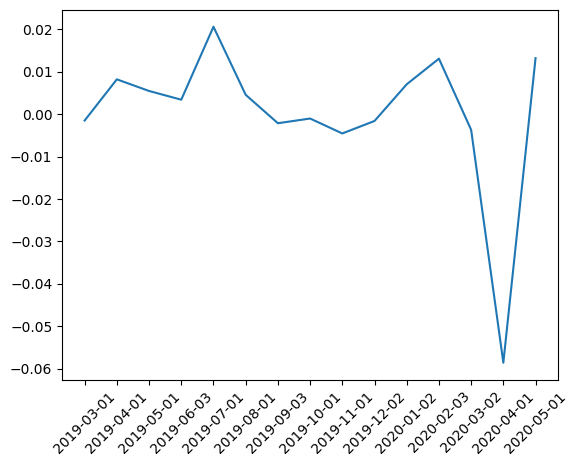

In [50]:
# without cost
plt.plot(pnl_dict.keys(), pnl_dict.values())
plt.xticks(rotation=45)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, '2019-03-01'),
  Text(1, 0, '2019-04-01'),
  Text(2, 0, '2019-05-01'),
  Text(3, 0, '2019-06-03'),
  Text(4, 0, '2019-07-01'),
  Text(5, 0, '2019-08-01'),
  Text(6, 0, '2019-09-03'),
  Text(7, 0, '2019-10-01'),
  Text(8, 0, '2019-11-01'),
  Text(9, 0, '2019-12-02'),
  Text(10, 0, '2020-01-02'),
  Text(11, 0, '2020-02-03'),
  Text(12, 0, '2020-03-02'),
  Text(13, 0, '2020-04-01'),
  Text(14, 0, '2020-05-01')])

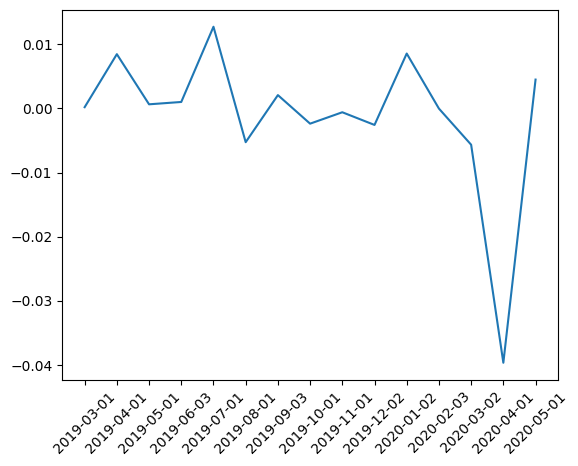

In [ ]:
# without cost
plt.plot(pnl_dict.keys(), pnl_dict.values())
plt.plot(pnl_dict.keys(), pnl_dict.values()qrumsum())
plt.xticks(rotation=45)


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32],
 [Text(0, 0, '2016-03-01'),
  Text(1, 0, '2016-04-01'),
  Text(2, 0, '2016-05-02'),
  Text(3, 0, '2016-06-01'),
  Text(4, 0, '2016-07-01'),
  Text(5, 0, '2016-08-01'),
  Text(6, 0, '2016-09-01'),
  Text(7, 0, '2016-10-03'),
  Text(8, 0, '2016-11-01'),
  Text(9, 0, '2016-12-01'),
  Text(10, 0, '2017-01-03'),
  Text(11, 0, '2017-02-01'),
  Text(12, 0, '2017-03-01'),
  Text(13, 0, '2017-04-03'),
  Text(14, 0, '2017-05-01'),
  Text(15, 0, '2017-06-01'),
  Text(16, 0, '2017-07-03'),
  Text(17, 0, '2017-08-01'),
  Text(18, 0, '2017-09-01'),
  Text(19, 0, '2017-10-02'),
  Text(20, 0, '2017-11-01'),
  Text(21, 0, '2017-12-01'),
  Text(22, 0, '2018-01-02'),
  Text(23, 0, '2018-02-01'),
  Text(24, 0, '2018-03-01'),
  Text(25, 0, '2018-04-02'),
  Text(26, 0, '2018-05-01'),
  Text(27, 0, '2018-06-01'),
  Text(28

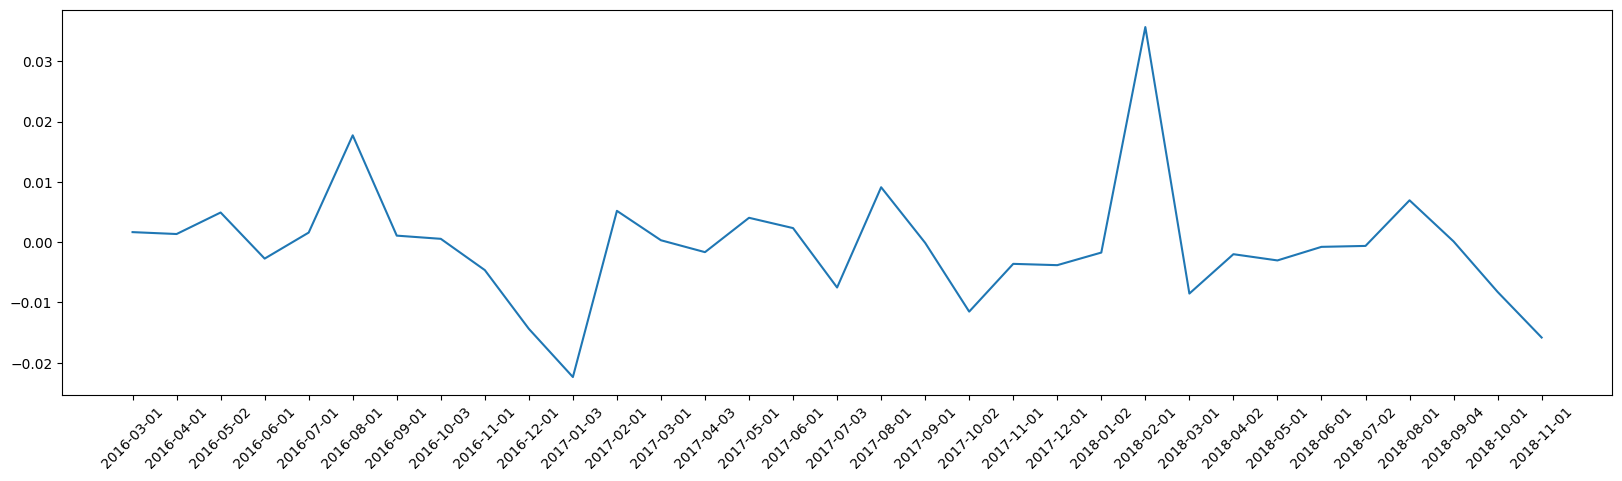

In [39]:
# without cost
plt.figure(figsize=(20, 5))
plt.plot(pnl_dict.keys(), pnl_dict.values())
plt.xticks(rotation=45)


In [182]:
portfolios[date][mask]


,Key,Value,weights
230,BIL,1,0.043093
378,BWX,1,0.036983
574,CWI,1,0.053785
787,EBND,1,0.058586
1133,FLRN,1,0.048282
1348,GNR,1,0.062497
1400,GXC,1,0.035934
1503,HYS,1,0.026822
1867,JNK,1,0.049981
2707,RWX,1,0.039555


In [173]:
weights = np.array([1/count_etf]*count_etf)

portfolio_returns = return_scenarios @ weights
# portfolio_returns.shape, portfolio_returns

alpha = 0.95

losses = -portfolio_returns
sorted_losses = np.sort(losses)[::-1]

var_index = int(s_samples * (1 - alpha))
# var_index = np.ceil(s_samples * (1 - alpha))

var = sorted_losses[var_index]
cvar_loss = sorted_losses[:var_index+1].mean()

var, cvar_loss, weights


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_39905/603988662.py:3: RuntimeWarning: divide by zero encountered in matmul
  portfolio_returns = return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_39905/603988662.py:3: RuntimeWarning: overflow encountered in matmul
  portfolio_returns = return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_39905/603988662.py:3: RuntimeWarning: invalid value encountered in matmul
  portfolio_returns = return_scenarios @ weights


(np.float64(0.3429517689090904),
 np.float64(0.4427231482572668),
 array([0.04761905, 0.04761905, 0.04761905, 0.04761905, 0.04761905,
        0.04761905, 0.04761905, 0.04761905, 0.04761905, 0.04761905,
        0.04761905, 0.04761905, 0.04761905, 0.04761905, 0.04761905,
        0.04761905, 0.04761905, 0.04761905, 0.04761905, 0.04761905,
        0.04761905]))

In [177]:
@beartype
def calculate_portfolio_returns(return_scenarios: np.ndarray, weights: np.ndarray) -> np.ndarray:
    return return_scenarios @ weights

@beartype
def minimize_cvar(weights: np.ndarray, return_scenarios: np.ndarray, alpha: float = 0.95) -> float:
    portfolio_returns = calculate_portfolio_returns(return_scenarios, weights)
    s_samples = portfolio_returns.shape[0]
    sorted_losses = np.sort(-portfolio_returns)[::-1]
    var_index = int(s_samples * (1 - alpha))
    var = sorted_losses[var_index]
    cvar_loss = sorted_losses[:var_index+1].mean()
    return cvar_loss

@beartype
def cvar_optimization(return_scenarios: np.ndarray, bound: tuple = (0, 0.5)) -> tuple[float, np.ndarray]:
    args = (return_scenarios,)
    count_etf = return_scenarios.shape[1]
    bounds = [bound] * count_etf
    weights = np.array([1/count_etf]*count_etf)
    constraints = {'type': 'ineq', 'fun': lambda x:  np.sum(x) - 1}
    result = minimize(fun=minimize_cvar, x0 = weights, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.fun, result.x


fun, weights = cvar_optimization(return_scenarios)
fun, weights

# portfolio_returns.shape


/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_39905/1599637805.py:3: RuntimeWarning: divide by zero encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_39905/1599637805.py:3: RuntimeWarning: overflow encountered in matmul
  return return_scenarios @ weights
/var/folders/nx/j52nwmrs4pl0zl8vk6l0n7zm0000gn/T/ipykernel_39905/1599637805.py:3: RuntimeWarning: invalid value encountered in matmul
  return return_scenarios @ weights


(np.float64(0.42031469152248785),
 array([0.04309268, 0.0369834 , 0.05378477, 0.05858621, 0.04828193,
        0.0624967 , 0.03593357, 0.02682233, 0.04998086, 0.03955531,
        0.06634109, 0.05204695, 0.0383235 , 0.038782  , 0.04667584,
        0.061108  , 0.05897161, 0.05604326, 0.05991145, 0.04572835,
        0.0205502 ]))

In [ ]:
@beartype
def portfolio_perfomance(weights: np.ndarray, meanReturns: pd.Series, covMatrix: pd.DataFrame) -> tuple[float, float]:
    expectedReturns = np.dot(weights.T, meanReturns)
    variance = np.dot(weights.T, np.dot(covMatrix, weights))
    return expectedReturns, variance


@beartype
def function_negative_sharpe(weights: np.ndarray, meanReturns: pd.Series, covMatrix: pd.DataFrame) -> float:
    expectedReturns, variance = portfolio_perfomance(weights, meanReturns, covMatrix)
    return -expectedReturns / variance


@beartype
def maximize_sharpe(meanReturns: pd.Series, covMatrix: pd.DataFrame, count_strategies: int, bound = (0.1, 2)) -> tuple[float, np.ndarray]:
    args = (meanReturns, covMatrix)
    bounds=(bound for _ in range(count_strategies))
    weights = np.array([1/count_strategies]*count_strategies)
    constraints = {'type': 'ineq', 'fun': lambda x:  np.sum(x) - 1}
    result = minimize(fun=function_negative_sharpe, x0 = weights, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.fun, result.x


@beartype
def function_variance(weights: np.ndarray, meanReturns: pd.Series, covMatrix: pd.DataFrame) -> float:
    return portfolio_perfomance(weights, meanReturns, covMatrix)[1]


@beartype
def minimize_variance(meanReturns: pd.Series, covMatrix: pd.DataFrame, count_strategies: int, bound = (0.1, 2)) -> tuple[float, np.ndarray]:
    args = (meanReturns, covMatrix)
    bounds = (bound for _ in range(count_strategies))
    weights = np.array([1/count_strategies]*count_strategies)
    constraints = {'type': 'ineq', 'fun': lambda x:  np.sum(x) - 1}
    result = minimize(fun=function_variance, x0 = weights, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.fun, result.x


@beartype
def function_mean(weights: np.ndarray, meanReturns: pd.Series, covMatrix: pd.DataFrame) -> float:
    return portfolio_perfomance(weights, meanReturns, covMatrix)[0]


@beartype
def efficient_optimization(meanReturns: pd.Series, covMatrix: pd.DataFrame, targetReturn: float, count_strategies: int, bound = (0.1, 2)) -> tuple[float, np.ndarray]:
    args = (meanReturns, covMatrix)
    bounds = (bound for _ in range(count_strategies))
    weights = np.array([1/count_strategies]*count_strategies)
    constraints = ({'type': 'ineq', 'fun': lambda x:  np.sum(x) - 1}, {'type': 'ineq', 'fun': lambda x:  function_mean(x, meanReturns, covMatrix) - targetReturn})
    result = minimize(fun=function_variance, x0 = weights, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.fun, result.x

        
@beartype
def efficient_frontier(min_variance_returns: float, max_sharpe_returns: float, meanReturns: pd.Series, covMatrix: pd.DataFrame, count_strategies: int) -> tuple[np.ndarray, list]:
    results = []
    # target_returns = np.linspace(min_variance_returns, max_sharpe_returns, 20)
    target_returns = np.linspace(max_sharpe_returns, min_variance_returns, 20)
    for targetReturn in target_returns:
        results.append(efficient_optimization(meanReturns, covMatrix, targetReturn, count_strategies)[0])
    return target_returns, results


weights = np.array([1/count_strategies]*count_strategies)

meanReturns, covMatrix = get_meanReturns_covMatrix(returns_df)
expectedReturns, variance = portfolio_perfomance(weights, meanReturns, covMatrix)
expectedReturns, variance, expectedReturns / variance

result, weights = maximize_sharpe(meanReturns, covMatrix, count_strategies)
max_sharpe_returns, max_sharpe_variance = portfolio_perfomance(weights, meanReturns, covMatrix)
max_sharpe_returns, max_sharpe_variance, max_sharpe_returns / max_sharpe_variance, weights


In [54]:
eigenvalues = np.linalg.eigvalsh(cov_matrix)
print(np.all(eigenvalues >= 0))
cov_matrix



True


array([[ 6.67280672e-11,  2.61261600e-10, -1.07336968e-10],
       [ 2.61261600e-10,  4.92916929e-09, -4.08684986e-09],
       [-1.07336968e-10, -4.08684986e-09,  2.13634388e-08]])

In [ ]:
# cov_matrix.values + 1e-5 * np.eye(cov_matrix.values.shape[0])
new_matrix = make_positive_semifinite_matrix(cov_matrix.values)
new_matrix


array([[1.00000000e+00, 3.99915263e-06, 9.48923596e-07],
       [3.99915263e-06, 1.00000000e+00, 7.02729853e-06],
       [9.48923596e-07, 7.02729853e-06, 1.00000000e+00]])

In [73]:
cov_matrix


array([[ 1.00000000e+00, -5.88443586e-06,  2.43500249e-06,
         3.27024646e-06,  2.05887437e-07, -2.31450988e-06,
         3.33131723e-06,  1.60175831e-06,  2.30463518e-06,
        -3.69959228e-08,  1.29746132e-06,  3.02389507e-06,
        -2.53095907e-06,  8.89245430e-07, -1.08822091e-06,
         1.89456047e-06, -1.76340489e-06, -6.51393741e-07,
         1.10311403e-06,  1.00372903e-06,  5.61549216e-06],
       [-5.88443586e-06,  1.00000000e+00, -4.73277355e-06,
         3.34363597e-06, -1.08458053e-06, -2.50902641e-06,
         1.49093549e-05,  4.49888807e-06,  3.42113850e-06,
         4.63457683e-06,  2.89152703e-06,  1.68281971e-06,
         2.78624067e-06, -1.20790509e-07,  3.58986389e-06,
         1.53263584e-06, -2.26298177e-06, -1.34275072e-06,
        -2.98156945e-07,  8.92849114e-06, -2.59984714e-06],
       [ 2.43500249e-06, -4.73277355e-06,  1.00000000e+00,
        -1.73504833e-06, -4.97793998e-07, -2.50049105e-06,
        -2.47989094e-06, -2.47248400e-06, -2.96281842e

In [ ]:
first_business_days[date_index[0]]


Timestamp('2019-01-02 00:00:00')

In [113]:
portfolios_rebalance[first_business_days.iloc[10].strftime("%Y-%m-%d")]


,Key,Value
0,BIL,1
1,RWX,1
2,SHM,1
3,SPSB,1
4,TFI,1
5,TOTL,1


In [94]:
a = portfolios_rebalance[first_business_days[date_index[0]].strftime('%Y-%m-%d')]
a['Key'].tolist()


['BIL', 'FLRN', 'SHM', 'SJNK', 'SPSB', 'SPTI', 'SPTS']

In [ ]:
initial_date = first_business_days.iloc[0]
all_etf = portfolios_rebalance[initial_date.strftime('%Y-%m-%d')]
all_etf


KeyError: 0

In [63]:
returns_rebalance[initial_date.strftime('%Y-%m-%d')]


,Date,BIL,SPTI
0,2016-01-04,0.000000,0.000000
1,2016-01-05,0.000000,0.000000
2,2016-01-06,-0.000438,0.002666
3,2016-01-07,0.000219,0.001330
4,2016-01-08,0.000000,0.000664
5,2016-01-11,0.000000,-0.000332
6,2016-01-12,0.000219,0.000996
7,2016-01-13,-0.000219,0.001989
8,2016-01-14,-0.000219,0.000000
9,2016-01-15,0.000000,0.002316
